In [1]:
import numpy as np
import scipy
import json
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D
from datetime import datetime
from qiskit.quantum_info import Pauli

np.set_printoptions(linewidth=200, precision=4, suppress=True)

In [2]:
# Initialize Pauli matrices

pauli_x = Pauli('X')
pauli_y = Pauli('Y')
pauli_z = Pauli('Z')
identity = Pauli('I')

X = pauli_x.to_matrix()
Y = pauli_y.to_matrix()
Z = pauli_z.to_matrix()
I = identity.to_matrix()

Ix1 = np.kron(X/2,I)
Iy1 = np.kron(Y/2,I)
Iz1 = np.kron(Z/2,I)
Ix2 = np.kron(I,X/2)
Iy2 = np.kron(I,Y/2)
Iz2 = np.kron(I,Z/2)

J = 696

In [3]:
U_cnot = np.array([[1,0,0,0],
                   [0,1,0,0],
                   [0,0,0,1],
                   [0,0,1,0]])

U_perm = np.array([[1,0,0,0],
                   [0,0,0,1],
                   [0,1,0,0],
                   [0,0,1,0]])

U_cz = np.array([[1,0,0,0],
                [0,1,0,0],
                [0,0,1,0],
                [0,0,0,-1]])

Unitary matrix --> Hamiltonian and pulse parameters = difficult

Pulse parameters --> Unitary matrix = easy

Method: change pulse parameters, calculate how similar the resulting Unitary matrix is to Target unitary matrix, compare and optimize

In [6]:
# Parameters for a 2 qubit Rx(pi/2) pulse, Hydrogen and Phosphorus

R1=R2=1
w_rf=6250
phi_rf=np.pi/2
t_rf=40e-6

w0=w_rf
w1_H=w1_P=6250


In [7]:
# 2 qubit Unitary matrix calculation from system Hamiltonian

def twoqubit_unitary(R1,R2,w_rf,phi_rf,t_rf,w0,w1_H,w1_P):
    
    H0 = 2*np.pi*(w0-w_rf)*Iz1+2*np.pi*(w0-w_rf)*Iz2

    HJ = 2*np.pi*J*(np.kron(Z,Z)/4)

    H1 = 2*np.pi*R1*w1_H*(np.cos(phi_rf)*Ix1+np.sin(phi_rf)*Iy1)+2*np.pi*R2*w1_P*(np.cos(phi_rf)*Ix2+np.sin(phi_rf)*Iy2)

    return scipy.linalg.expm(-1j*(H0+HJ+H1)*t_rf)



In [8]:
Rypi2 = twoqubit_unitary(R1,R2,w_rf,phi_rf,t_rf,w0,w1_H,w1_P)

In [9]:
rho = Iz1

rho_f = Rypi2 @ rho @ Rypi2.conj().T

rho_f

array([[ 0.0003+0.j    ,  0.    -0.j    ,  0.4993-0.0219j, -0.    -0.0139j],
       [ 0.    +0.j    ,  0.0003+0.j    , -0.    -0.0139j,  0.4993+0.0219j],
       [ 0.4993+0.0219j, -0.    +0.0139j, -0.0003+0.j    ,  0.    +0.j    ],
       [-0.    +0.0139j,  0.4993-0.0219j,  0.    -0.j    , -0.0003+0.j    ]])

In [10]:
print(np.trace(rho_f @ Ix1))
print(np.trace(rho_f @ Iy1))
print(np.trace(rho_f @ Iz1))


(0.9986568311717521+0j)
(-6.591949208711867e-17+0j)
(0.000608575287973024+0j)


1. Create unitary operator

$$
U = R_{-z}^2\left(\frac{\pi}{4}\right)
    R_{-y}^2\left(\frac{\pi}{4}\right)
    R_{z}^1\left(\frac{\pi}{4}\right)
    R_{y}^1\left(\frac{\pi}{4}\right)
$$

In [11]:
# Rotation Rz through euler angles Rz(theta)=Rx(pi/2)Ry(theta)Rx(-pi/2)

R1 = twoqubit_unitary(0,1,6250,0,40e-6,6250,6250,6250)
R2 = twoqubit_unitary(0,1,6250,-np.pi/2,20e-6,6250,6250,6250)
R3 = twoqubit_unitary(0,1,6250,np.pi,40e-6,6250,6250,6250)

R2_zpi4 = R1 @ R2 @ R3

print(R2_zpi4)



[[ 0.9409+0.3308j  0.0729-0.j      0.    +0.j      0.    +0.j    ]
 [-0.0729-0.j      0.9409-0.3308j  0.    +0.j      0.    +0.j    ]
 [ 0.    +0.j      0.    +0.j      0.8983+0.4334j -0.0724-0.j    ]
 [ 0.    +0.j      0.    +0.j      0.0724+0.j      0.8983-0.4334j]]


In [12]:
# Rotation Ry

R2_ypi4 = twoqubit_unitary(0,1,6250,-np.pi/2,20e-6,6250,6250,6250)

In [13]:
# Rotation Rz through euler angles Rz(theta)=Rx(pi/2)Ry(theta)Rx(-pi/2)

R1 = twoqubit_unitary(1,0,6250,0,40e-6,6250,6250,6250)
R2 = twoqubit_unitary(1,0,6250,np.pi/2,20e-6,6250,6250,6250)
R3 = twoqubit_unitary(1,0,6250,np.pi,40e-6,6250,6250,6250)

R1zpi4 = R1 @ R2 @ R3

print(R1zpi4)


[[ 0.8983-0.4334j  0.    +0.j      0.0724-0.j      0.    +0.j    ]
 [ 0.    +0.j      0.9409-0.3308j  0.    +0.j     -0.0729-0.j    ]
 [-0.0724+0.j      0.    +0.j      0.8983+0.4334j  0.    +0.j    ]
 [ 0.    +0.j      0.0729-0.j      0.    +0.j      0.9409+0.3308j]]


In [14]:
# Rotation Ry

R1ypi4 = twoqubit_unitary(1,0,6250,np.pi/2,20e-6,6250,6250,6250)

U achieved using hard pulses

In [15]:
U = R2_zpi4 @ R2_ypi4 @ R1zpi4 @ R1ypi4

print(U)

[[ 0.8392-0.1136j  0.3991-0.0133j -0.2826+0.0629j -0.1991-0.j    ]
 [-0.3088+0.2879j  0.6379-0.4843j  0.0969-0.107j  -0.3259+0.2307j]
 [ 0.1646+0.2581j  0.0969+0.107j   0.5435+0.7115j  0.1871+0.221j ]
 [-0.1047-0.j      0.4162-0.0706j -0.305 +0.0258j  0.8392-0.1136j]]


Strongly Modulated Pulse optimization

In [14]:

# SMP following SpinQ manual 

# constants
n = 2
w0 = 6250
w1_max = 6250

# Compute fidelity aka loss function

def fidelity_func_smp(R_H, R_P, phi_H, phi_P, dt, w1_H, w1_P, U_target):

    U = np.eye(4, dtype=complex)

    HJ = 2*np.pi*J*(np.kron(Z,Z)/4)

    for k in range(len(R_H)):

        Hrf = (
            2*np.pi*R_H[k]*w1_H*(np.cos(phi_H[k])*Ix1 + np.sin(phi_H[k])*Iy1)
            +
            2*np.pi*R_P[k]*w1_P*(np.cos(phi_P[k])*Ix2 + np.sin(phi_P[k])*Iy2)
        )

        H = HJ + Hrf

        U = scipy.linalg.expm(-1j * H * dt) @ U

    d = U_target.shape[0]

    return 1 - np.abs(np.trace(U_target.conj().T @ U)) / d

# Gradient descent algorithm

# Calculate numerical gradient

def num_grad(
        R_H, R_P,
        phi_H, phi_P,
        N, dt,
        w1_H, w1_P,
        U_target,
        d=1e-2):
    
    grad_R_H = np.zeros_like(R_H)
    grad_R_P = np.zeros_like(R_P)
    grad_phi_H = np.zeros_like(phi_H)
    grad_phi_P = np.zeros_like(phi_P)

    eps = 1e-6
    # per-component increments
    dR_H = np.maximum(d*R_H, eps)
    dR_P = np.maximum(d*R_P, eps)
    dphi_H = np.maximum(d*np.abs(phi_H), eps)
    dphi_P = np.maximum(d*np.abs(phi_P), eps)

    Q0 = fidelity_func_smp(R_H, R_P, phi_H, phi_P, dt, w1_H, w1_P, U_target)

    for k in range(N):
        R_H_temp = R_H.copy()
        R_H_temp[k] += dR_H[k]
        grad_R_H[k] = (fidelity_func_smp(R_H_temp, R_P, phi_H, phi_P, dt, w1_H, w1_P, U_target) - Q0)/dR_H[k]
        
        R_P_temp = R_P.copy()
        R_P_temp[k] += dR_P[k]
        grad_R_P[k] = (fidelity_func_smp(R_H, R_P_temp, phi_H, phi_P, dt, w1_H, w1_P, U_target) - Q0)/dR_P[k]
        
        phi_H_temp = phi_H.copy()
        phi_H_temp[k] += dphi_H[k]
        grad_phi_H[k] = (fidelity_func_smp(R_H, R_P, phi_H_temp, phi_P, dt, w1_H, w1_P, U_target) - Q0)/dphi_H[k]

        phi_P_temp = phi_P.copy()
        phi_P_temp[k] += dphi_P[k]
        grad_phi_P[k] = (fidelity_func_smp(R_H, R_P, phi_H, phi_P_temp, dt, w1_H, w1_P, U_target) - Q0)/dphi_P[k]


    return grad_R_H, grad_R_P, grad_phi_H, grad_phi_P

# Save to json file

def export_to_json_SMP(filename, title, fidelity, totalpulsewidth, slices, R, phi, omega_rf, owner="Unkown"):
    
    R = np.asarray(R).flatten()
    phi = np.asarray(phi).flatten()
    omega_rf = np.asarray(omega_rf).flatten()
    
    dt = totalpulsewidth / slices

    channel1_pulses = []
    channel2_pulses = []

    for k in range(slices):
        
        amplitude = 100 * float(R[k]) # in %
        phase = float(np.degrees(phi[k]) % 360)
        detuning = float(w0 - omega_rf[k])

        pulse_entry = {
            "detuning": detuning,
            "phase": phase,
            "amplitude": amplitude,
            "width": float(dt)
        }

        # Same pulse on both channels (modify if needed)
        channel1_pulses.append(pulse_entry)
        channel2_pulses.append(pulse_entry.copy())
        
        data = {
        "description": {
            "TITLE": title,
            "OWNER": owner,
            "DATE": datetime.now().strftime("%d-%m-%Y"),
            "FIDELITY": float(fidelity),
            "TOTALPULSEWIDTH": float(totalpulsewidth),
            "SLICES": int(slices)
        },
        "parameters": {
            "offset": [
                {
                    "channel1_pulsefre_offset": 0,
                    "channel1_framefre_offset": 0,
                    "channel2_pulsefre_offset": 0,
                    "channel2_framefre_offset": 0
                }
            ]
        },
        "pulse": {
            "channel1_pulse": channel1_pulses,
            "channel2_pulse": channel2_pulses
        }
    }

    with open(filename, "w") as f:
        json.dump(data, f, indent=4)

    print(f"Pulse file saved to {filename}")


In [15]:
# SMP Gradient descent loop

U_target = U

J = 696
T = 1e-3
N = 500  # maybe add more divisions?
dt = T/N
w1_H = w1_P = 6250

# initialize
R_H = np.full(N, 1.0, dtype=float)
R_P = np.full(N, 1.0, dtype=float)
phi_H = np.zeros(N, dtype=float)
phi_P = np.zeros(N, dtype=float)

learn_rate = 0.05
iter = 200

for i in range(iter):
    grad_R_H, grad_R_P, grad_phi_H, grad_phi_P = num_grad(
    R_H, R_P,
    phi_H, phi_P,
    N, dt,
    w1_H, w1_P,
    U_target,
    d=0.02
)
    
    R_H -= learn_rate * grad_R_H
    R_P -= learn_rate * grad_R_P
    phi_H -= learn_rate * grad_phi_H
    phi_P -= learn_rate * grad_phi_P
    
    R_H = np.clip(R_H,0,1)
    R_P = np.clip(R_P,0,1)
    phi_H = phi_H % (2*np.pi)
    phi_P = phi_P % (2*np.pi)
    
    if i % 10 == 0 or i == iter-1:
        print(f"Iteration {i}, Fidelity={1-fidelity_func_smp(R_H, R_P, phi_H, phi_P, dt, w1_H, w1_P, U_target):.6f}")
        
pulse_fidelity = 1-fidelity_func_smp(R_H, R_P, phi_H, phi_P, dt, w1_H, w1_P, U_target)

Iteration 0, Fidelity=0.143218
Iteration 10, Fidelity=0.211247
Iteration 20, Fidelity=0.312089
Iteration 30, Fidelity=0.423404
Iteration 40, Fidelity=0.523587
Iteration 50, Fidelity=0.601875
Iteration 60, Fidelity=0.657940
Iteration 70, Fidelity=0.696445
Iteration 80, Fidelity=0.722649
Iteration 90, Fidelity=0.740667
Iteration 100, Fidelity=0.753289
Iteration 110, Fidelity=0.762309
Iteration 120, Fidelity=0.768867
Iteration 130, Fidelity=0.773700
Iteration 140, Fidelity=0.777300
Iteration 150, Fidelity=0.780003
Iteration 160, Fidelity=0.782047
Iteration 170, Fidelity=0.783603
Iteration 180, Fidelity=0.784796
Iteration 190, Fidelity=0.785720
Iteration 199, Fidelity=0.786377


In [25]:
export_to_json_SMP("TestSMP_hardpulses","pulses1",pulse_fidelity,T,N,R,phi,omega_rf,"andreroque")

Pulse file saved to TestSMP_hardpulses


In [36]:
U_target = U_cnot

J = 696
T = 200e-6
N = 50  # maybe add more divisions?
dt = T/N

# initialize
R = np.full(N, 1.0, dtype=float)
phi = np.zeros(N, dtype=float)
omega_rf = np.full(N, w0, dtype=float)
dts = np.full(N, dt, dtype=float)

learn_rate = 0.05 # 500 iterations 0.01 is small - 38 minutes - fidelity = 0.7244; 500 iterations 0.05 - plateau at fidelity = 0.74
iter = 200

for i in range(iter):
    grad_R,grad_phi,grad_omega = num_grad(R, phi, omega_rf, dts, U_target) #,grad_dt
    
    R -= learn_rate * grad_R
    phi -= learn_rate * grad_phi
    omega_rf -= learn_rate * grad_omega
    #dts -= learn_rate * grad_dt
    
    R = np.clip(R,0,1)
    phi = phi % (2*np.pi)
    
    if i % 10 == 0 or i == iter-1:
        print(f"Iteration {i}, Fidelity={fidelity(R, phi, omega_rf, dts, U_target):.6f}")

Iteration 0, Fidelity=0.352359
Iteration 10, Fidelity=0.385224
Iteration 20, Fidelity=0.412809
Iteration 30, Fidelity=0.435352
Iteration 40, Fidelity=0.453416
Iteration 50, Fidelity=0.467692
Iteration 60, Fidelity=0.478872
Iteration 70, Fidelity=0.487583
Iteration 80, Fidelity=0.494357
Iteration 90, Fidelity=0.499630
Iteration 100, Fidelity=0.503748
Iteration 110, Fidelity=0.506982
Iteration 120, Fidelity=0.509543
Iteration 130, Fidelity=0.511589
Iteration 140, Fidelity=0.513244
Iteration 150, Fidelity=0.514599
Iteration 160, Fidelity=0.515724
Iteration 170, Fidelity=0.516671
Iteration 180, Fidelity=0.517480
Iteration 190, Fidelity=0.518180
Iteration 199, Fidelity=0.518737


GRAPE Algorithm

In [ ]:
# Gradient Ascent - GRAPE - same channel

# a bit different from the basic SMP, the parameter phi is omitted, collapsed into the amplitude which now differs for each orthogonal direction x, y

# constants
n = 2
d = 2**n
#wH = 27e6
#wP = 11e6
#w1H = w1P after calibration
w1_max = 6250

H_x = 2*np.pi*w1_max*(Ix1+Ix2)
H_y = 2*np.pi*w1_max*(Iy1+Iy2)

# H_0 = 0 because on resonance, only include when detuning or counteracting chemical shift mismatch
H_J = 2*np.pi*J*(np.kron(Z,Z)/4)

def p_calc(R_x, R_y, U_target):
    P_list = []
    P = U_target.copy()
    
    for k in reversed(range(N)):
        H = H_J + R_x[k]*H_x + R_y[k]*H_y
        Uk = scipy.linalg.expm(-1j * H * dt)
        P = Uk.conj().T @ P
        P_list.insert(0, P)

    return P_list

def x_calc(R_x,R_y):
    X_list = []
    U = np.eye(d, dtype=complex)
    
    for k in range(N):
        H = H_J + R_x[k]*H_x + R_y[k]*H_y
        Uk = scipy.linalg.expm(-1j * H * dt)
        U = Uk @ U
        X_list.append(U)

    return X_list, U

def fidelity_grape(U):
    return np.abs(np.trace(U_target.conj().T @ U))/d

def grape_grad(R_x, R_y, U_target):
    
    X_list, U_final = x_calc(R_x, R_y)
    P_list = p_calc(R_x, R_y, U_target)
    
    H_x = 2*np.pi*w1_max*(Ix1+Ix2)
    H_y = 2*np.pi*w1_max*(Iy1+Iy2)
    H_J = 2*np.pi*J*(np.kron(Z,Z)/4)
    
    phi = np.trace(U_target.conj().T @ U_final)
    F0 = fidelity_grape(U_final)
    
    grad_x = np.zeros((N,1))
    grad_y = np.zeros((N,1))
    
    for k in range(N):
        Xk = X_list[k]
        Pk = P_list[k]
        
        dX = -1j * dt * H_x @ Xk
        dY = -1j * dt * H_y @ Xk
        
        grad_x[k] = (2/d) * np.real(
            np.trace(Pk.conj().T @ dX) * np.conj(phi)
        )
        
        grad_y[k] = (2/d) * np.real(
            np.trace(Pk.conj().T @ dY) * np.conj(phi)
        )
        
    return F0, grad_x, grad_y, U_final

def export_to_json_GRAPE(filename, title, fidelity, totalpulsewidth, slices, R_x, R_y, owner="Unkown"):
    
    R_x = np.asarray(R_x).flatten()
    R_y = np.asarray(R_y).flatten()
    
    dt = totalpulsewidth / slices

    channel1_pulses = []
    channel2_pulses = []

    for k in range(slices):

        rx = float(R_x[k])
        ry = float(R_y[k])

        amplitude = 100 * np.sqrt(rx**2 + ry**2) # in %
        phase = np.degrees(np.arctan2(ry, rx))  # convert to degrees

        pulse_entry = {
            "detuning": 0,
            "phase": float(phase),
            "amplitude": float(amplitude),
            "width": float(dt)
        }

        # Same pulse on both channels (modify if needed)
        channel1_pulses.append(pulse_entry)
        channel2_pulses.append(pulse_entry.copy())
        
        data = {
        "description": {
            "TITLE": title,
            "OWNER": owner,
            "DATE": datetime.now().strftime("%d-%m-%Y"),
            "FIDELITY": float(fidelity),
            "TOTALPULSEWIDTH": float(totalpulsewidth),
            "SLICES": int(N)
        },
        "parameters": {
            "offset": [
                {
                    "channel1_pulsefre_offset": 0,
                    "channel1_framefre_offset": 0,
                    "channel2_pulsefre_offset": 0,
                    "channel2_framefre_offset": 0
                }
            ]
        },
        "pulse": {
            "channel1_pulse": channel1_pulses,
            "channel2_pulse": channel2_pulses
        }
    }

    with open(filename, "w") as f:
        json.dump(data, f, indent=4)

    print(f"Pulse file saved to {filename}")
    

In [30]:

#wP = 11e6# Gradient Ascent - GRAPE - different channels

# a bit different from the basic SMP, the parameter phi is omitted, collapsed into the amplitude which now differs for each orthogonal direction x, y

# constants
n = 2
d = 2**n
#wH = 27e6
#w1H = w1P after calibration
w1_max = 6250

H_x_H = 2*np.pi*w1_max*(Ix1)
H_x_P = 2*np.pi*w1_max*(Ix2)
H_y_H = 2*np.pi*w1_max*(Iy1)
H_y_P = 2*np.pi*w1_max*(Iy2)

# H_0 = 0 because working on resonance. Only include when detuning or counteracting chemical shift mismatch

def p_calc_2channel(Rx_H, Ry_H, Rx_P, Ry_P, U_target, J, T, N):
    P_list = []
    P = U_target.copy()
    dt = T/N
    H_J = 2*np.pi*J*(np.kron(Z,Z)/4)
    
    for k in reversed(range(N)):
        H = H_J + Rx_H[k]*H_x_H + Ry_H[k]*H_y_H + Rx_P[k]*H_x_P + Ry_P[k]*H_y_P
        Uk = scipy.linalg.expm(-1j * H * dt)
        P = Uk.conj().T @ P
        P_list.insert(0, P)

    return P_list

def x_calc_2channel(Rx_H, Ry_H, Rx_P, Ry_P, J, T, N):
    X_list = []
    U = np.eye(d, dtype=complex)
    dt = T/N
    H_J = 2*np.pi*J*(np.kron(Z,Z)/4)
    
    for k in range(N):
        H = H_J + Rx_H[k]*H_x_H + Ry_H[k]*H_y_H + Rx_P[k]*H_x_P + Ry_P[k]*H_y_P
        Uk = scipy.linalg.expm(-1j * H * dt)
        U = Uk @ U
        X_list.append(U)

    return X_list, U

def fidelity_grape(U, U_target):
    phi = np.trace(U_target.conj().T @ U)
    return np.abs(phi)**2/d**2

def grape_grad_2channel(Rx_H, Ry_H, Rx_P, Ry_P, U_target, J, T, N):
    
    X_list, U_final = x_calc_2channel(Rx_H, Ry_H, Rx_P, Ry_P, J, T, N)
    P_list = p_calc_2channel(Rx_H, Ry_H, Rx_P, Ry_P, U_target, J, T, N)
    dt = T/N
    
    phi = np.trace(U_target.conj().T @ U_final)
    F0 = fidelity_grape(U_final, U_target)
    
    grad_Rx_H = np.zeros(N)
    grad_Ry_H = np.zeros(N)
    grad_Rx_P = np.zeros(N)
    grad_Ry_P = np.zeros(N)
    
    for k in range(N):
        Xk = X_list[k]
        Pk = P_list[k]
        
        dX_Rx_H = -1j * dt * H_x_H @ Xk
        dX_Ry_H = -1j * dt * H_y_H @ Xk
        dX_Rx_P = -1j * dt * H_x_P @ Xk
        dX_Ry_P = -1j * dt * H_y_P @ Xk

        grad_Rx_H[k] = 2 * np.real(
            np.trace(Pk.conj().T @ dX_Rx_H) * np.conj(phi)
        )

        grad_Ry_H[k] = 2 * np.real(
            np.trace(Pk.conj().T @ dX_Ry_H) * np.conj(phi)
        )

        grad_Rx_P[k] = 2 * np.real(
            np.trace(Pk.conj().T @ dX_Rx_P) * np.conj(phi)
        )

        grad_Ry_P[k] = 2 * np.real(
            np.trace(Pk.conj().T @ dX_Ry_P) * np.conj(phi)
        )
        
    return (F0, grad_Rx_H, grad_Ry_H, grad_Rx_P, grad_Ry_P, U_final)

def pulse_optimize_grape(U_target, J, T, N, learn_rate, max_iter, startParameters = None):
    
    #print("Target matrix: \n", U_target)

    dt = T/N

    #print("dt = ",dt) # debug

    # initialize
    
    if startParameters is not None:
        Rx_H,Ry_H,Rx_P,Ry_P = startParameters
    else:
        Rx_H = np.full(N, 0.2)
        Ry_H = np.full(N, 0.2)
        Rx_P = np.full(N, 0.2)
        Ry_P = np.full(N, 0.2)

    lr = learn_rate
    maxi = max_iter

    for i in range(maxi):

        F, gRxH, gRyH, gRxP, gRyP, Ufinal = grape_grad_2channel(
            Rx_H, Ry_H, Rx_P, Ry_P, U_target, J, T, N
        )

        Rx_H += lr * gRxH
        Ry_H += lr * gRyH
        Rx_P += lr * gRxP
        Ry_P += lr * gRyP

        # Clip amplitudes
        Rx_H = np.clip(Rx_H, -1, 1)
        Ry_H = np.clip(Ry_H, -1, 1)
        Rx_P = np.clip(Rx_P, -1, 1)
        Ry_P = np.clip(Ry_P, -1, 1)

        #if i % 100 == 0:
        #    print(f"Iter {i}, Fidelity = {F:.6f}")
        
        if F > 0.999:
            print("Converged.")
            break
    
    print("Final fidelity:", F)
    #print("Final matrix: \n", Ufinal)
    return Rx_H, Ry_H, Rx_P, Ry_P, F

def export_to_json_GRAPE_2channel(
    filename,
    title,
    fidelity,
    totalpulsewidth,
    slices,
    Rx_H,
    Ry_H,
    Rx_P,
    Ry_P,
    owner="Unknown"
):
    """
    Export GRAPE two-channel pulse to SpinQLab JSON format.
    """

    Rx_H = np.asarray(Rx_H).flatten()
    Ry_H = np.asarray(Ry_H).flatten()
    Rx_P = np.asarray(Rx_P).flatten()
    Ry_P = np.asarray(Ry_P).flatten()

    dt = totalpulsewidth / slices

    channel1_pulses = []
    channel2_pulses = []

    for k in range(slices):

        amplitude_H = 100 * np.sqrt(Rx_H[k]**2 + Ry_H[k]**2)
        phase_H = np.degrees(np.arctan2(Ry_H[k], Rx_H[k])) % 360

        amplitude_P = 100 * np.sqrt(Rx_P[k]**2 + Ry_P[k]**2)
        phase_P = np.degrees(np.arctan2(Ry_P[k], Rx_P[k])) % 360

        channel1_pulses.append({
            "detuning": 0,
            "phase": float(phase_H),
            "amplitude": float(amplitude_H),
            "width": float(dt)
        })

        channel2_pulses.append({
            "detuning": 0,
            "phase": float(phase_P),
            "amplitude": float(amplitude_P),
            "width": float(dt)
        })

    data = {
        "description": {
            "TITLE": title,
            "OWNER": owner,
            "DATE": datetime.now().strftime("%d-%m-%Y"),
            "FIDELITY": float(fidelity),
            "TOTALPULSEWIDTH": float(totalpulsewidth),
            "SLICES": int(slices)
        },
        "parameters": {
            "offset": [{
                "channel1_pulsefre_offset": 0,
                "channel1_framefre_offset": 0,
                "channel2_pulsefre_offset": 0,
                "channel2_framefre_offset": 0
            }]
        },
        "pulse": {
            "channel1_pulse": channel1_pulses,
            "channel2_pulse": channel2_pulses
        }
    }

    with open(filename, "w") as f:
        json.dump(data, f, indent=4)

    print(f"Pulse file saved to {filename}")
    
def plot_pulse_from_json(json_file):

    with open(json_file, "r") as f:
        data = json.load(f)

    ch1 = data["pulse"]["channel1_pulse"]
    ch2 = data["pulse"]["channel2_pulse"]

    amp1 = np.array([p["amplitude"] for p in ch1])
    phase1 = np.array([p["phase"] for p in ch1])
    width1 = np.array([p["width"] for p in ch1])

    amp2 = np.array([p["amplitude"] for p in ch2])
    phase2 = np.array([p["phase"] for p in ch2])
    width2 = np.array([p["width"] for p in ch2])

    # Start time of each slice
    t = np.concatenate(([0], np.cumsum(width1[:-1])))

    # Phase colormap
    norm = mcolors.Normalize(vmin=0, vmax=360)
    cmap = plt.cm.hsv

    colors1 = cmap(norm(phase1))
    colors2 = cmap(norm(phase2))

    fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True, constrained_layout=True)

    # Channel 1
    axs[0].bar(
        t,
        amp1,
        width=width1,
        color=colors1,
        align="edge",
        edgecolor="none"
    )
    axs[0].set_ylabel("Amplitude (%)")
    axs[0].set_title("Channel 1 - Hydrogen")
    axs[0].set_xlim([0,0.003])
    axs[0].set_ylim([0,100])
    
    # Channel 2
    axs[1].bar(
        t,
        amp2,
        width=width2,
        color=colors2,
        align="edge",
        edgecolor="none"
    )
    axs[1].set_ylabel("Amplitude (%)")
    axs[1].set_xlabel("Time")
    axs[1].set_title("Channel 2 - Phosphorus")
    axs[1].set_xlim([0,0.003])
    axs[1].set_ylim([0,100])
    
    # Phase colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axs)
    cbar.set_label("Phase (deg)")

    plt.show()

def grab_state_matrix(matrix):
    real = np.array(matrix["real"])
    imag = np.array(matrix["imag"])
    # Construct complex matrix
    rho = real + 1j * imag
    # Reshape into 4x4 matrix
    rho = rho.reshape((4,4))  
    return rho
    
def plot_density_matrix(rho):

    n = rho.shape[0]

    real = np.real(rho)
    imag = np.imag(rho)

    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')

    xpos, ypos = np.meshgrid(np.arange(n), np.arange(n))
    xpos = xpos.flatten()
    ypos = ypos.flatten()

    zpos = np.zeros(n*n)

    dx = dy = 0.35

    real_vals = real.flatten()
    imag_vals = imag.flatten()

    # shift bars slightly left/right
    xpos_real = xpos - 0.2
    xpos_imag = xpos + 0.2

    # colors
    real_colors = ["blue" if v >= 0 else "cyan" for v in real_vals]
    imag_colors = ["red" if v >= 0 else "orange" for v in imag_vals]

    # real bars
    ax.bar3d(
        xpos_real,
        ypos,
        zpos,
        dx,
        dy,
        real_vals,
        color=real_colors,
        shade=True,
        label="Real"
    )

    # imaginary bars
    ax.bar3d(
        xpos_imag,
        ypos,
        zpos,
        dx,
        dy,
        imag_vals,
        color=imag_colors,
        shade=True,
        label="Imag"
    )

    labels = ['00','01','10','11'][:n]
    
    # Clean grid
    ax.grid(True)

    ax.xaxis._axinfo["grid"]['color'] = (0.8,0.8,0.8,0.4)
    ax.yaxis._axinfo["grid"]['color'] = (0.8,0.8,0.8,0.4)
    ax.zaxis._axinfo["grid"]['color'] = (0.8,0.8,0.8,0.4)

    # Remove wall shading
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))

    ax.set_xlabel("Column", labelpad=15)
    ax.set_ylabel("Row", labelpad=15)
    ax.set_zlabel("Value", labelpad=10)

    ax.set_xticklabels(labels, rotation=30)
    ax.set_yticklabels(labels, rotation=-30)

    fig.subplots_adjust(left=0.05, right=0.95, bottom=0.15, top=0.9)

    ax.set_title("Density Matrix")
    
    ax.view_init(elev=25, azim=-55)

    # ax.set_zlim(-1,1)

    # plt.tight_layout()
    plt.show()
    
def plot_density_matrix_separate(rho):

    n = rho.shape[0]

    real = np.real(rho)
    imag = np.imag(rho)

    fig = plt.figure(figsize=(12,5))

    ax1 = fig.add_subplot(121, projection='3d')
    ax2 = fig.add_subplot(122, projection='3d')

    axes = [ax1, ax2]

    labels = ['00','01','10','11'][:n]

    for ax, matrix, title in zip(
        axes,
        [real, imag],
        ["Real part", "Imaginary part"]
    ):

        xpos, ypos = np.meshgrid(np.arange(n), np.arange(n))
        xpos = xpos.flatten()
        ypos = ypos.flatten()

        values = matrix.flatten()

        colors = ["red" if v < 0 else "blue" for v in values]

        ax.bar3d(
            xpos,
            ypos,
            np.zeros_like(values),
            0.5,
            0.5,
            values,
            color=colors,
            shade=True
        )

        ax.set_xticks(range(n))
        ax.set_yticks(range(n))

        ax.set_xticklabels(labels)
        ax.set_yticklabels(labels)

        ax.set_xlabel("Column")
        ax.set_ylabel("Row")
        ax.set_zlabel("Value")
        
        ax.set_zlim(0,1)
        ax.set_title(title)
        ax.view_init(elev=25, azim=-55)

    plt.show()

In [31]:
# learning loop

np.random.seed(1234)
U_target = U_cnot
print("Target matrix: \n", U_target)

J = 696
T = 100e-3
N = 5000  # add more divisions if the fidelity doesnt increase monotonically
dt = T/N

print("dt = ",dt)

# initialize
R_x = 0.2 * np.random.rand(N,1)
R_y = 0.2 * np.random.rand(N,1)

learn_rate = 0.01
max_iter = 5000
fid_history = []

for i in range(max_iter):

    F, grad_x, grad_y, Ufinal = grape_grad(R_x, R_y, U_target)

    # update
    R_x_new = R_x + learn_rate * grad_x
    R_y_new = R_y + learn_rate * grad_y

    R_x_new = np.clip(R_x_new, -1, 1)
    R_y_new = np.clip(R_y_new, -1, 1)
    
    R_x = R_x_new
    R_y = R_y_new

    fid_history.append(F)

    if i % 100 == 0:
        print(f"Iter {i}, Fidelity = {F:.6f}, lr = {learn_rate:.6e}")

    if F > 0.999:
        print("Converged.")
        break

print("Final fidelity:", F)
print("Final matrix: \n", Ufinal)
print(R_x, R_y)

Target matrix: 
 [[1 0 0 0]
 [0 1 0 0]
 [0 0 0 1]
 [0 0 1 0]]
dt =  2e-05
Iter 0, Fidelity = 0.084315, lr = 1.000000e-02
Iter 100, Fidelity = 0.344374, lr = 1.000000e-02
Iter 200, Fidelity = 0.434962, lr = 1.000000e-02
Iter 300, Fidelity = 0.387223, lr = 1.000000e-02


KeyboardInterrupt: 

In [137]:
# learning loop --- CNOT
# NOTES:
# 
np.random.seed(1234)

J = 696
T = 1e-3    # 1ms so J coupling spin-spin interactions have time to evolve
N = 500     # add more divisions if the fidelity doesnt increase monotonically. dt has to be small enough

start_parameters = np.array([np.full(N, 0.2),
                             np.full(N, 0.2),
                             np.full(N, 0.2),
                             np.full(N, 0.2)])

Rx_H, Ry_H, Rx_P, Ry_P, F = pulse_optimize_grape(U_cnot,J,T,N,0.01,5000,start_parameters)


Final fidelity: 0.9672955821952735


In [135]:
export_to_json_GRAPE_2channel("TestGRAPE_cnot_point2_start.json", "1stCNOT", F, T, N, Rx_H, Ry_H, Rx_P, Ry_P, "andreroque")

Pulse file saved to TestGRAPE_cnot_point2_start.json


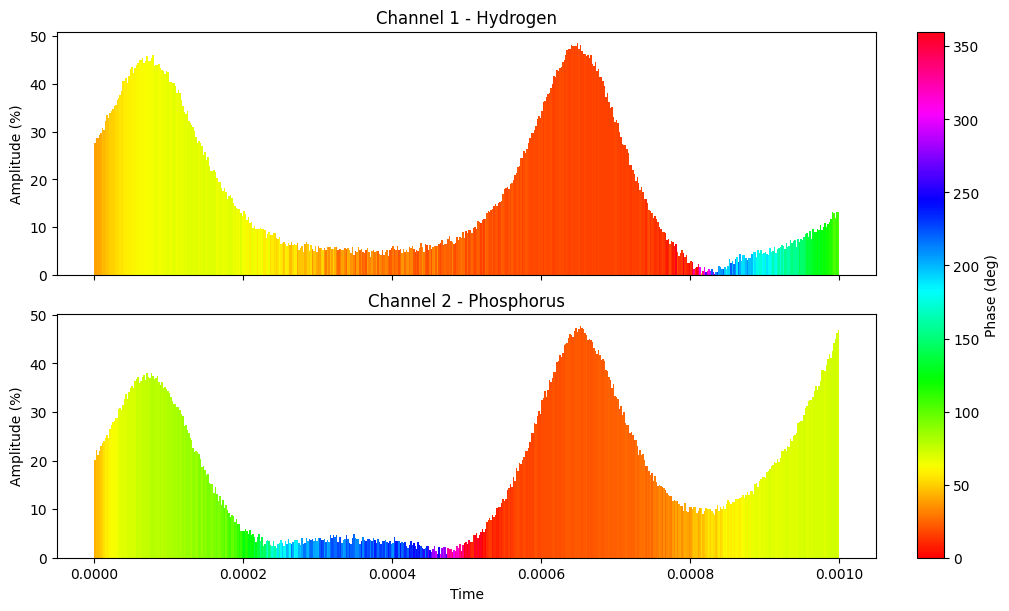

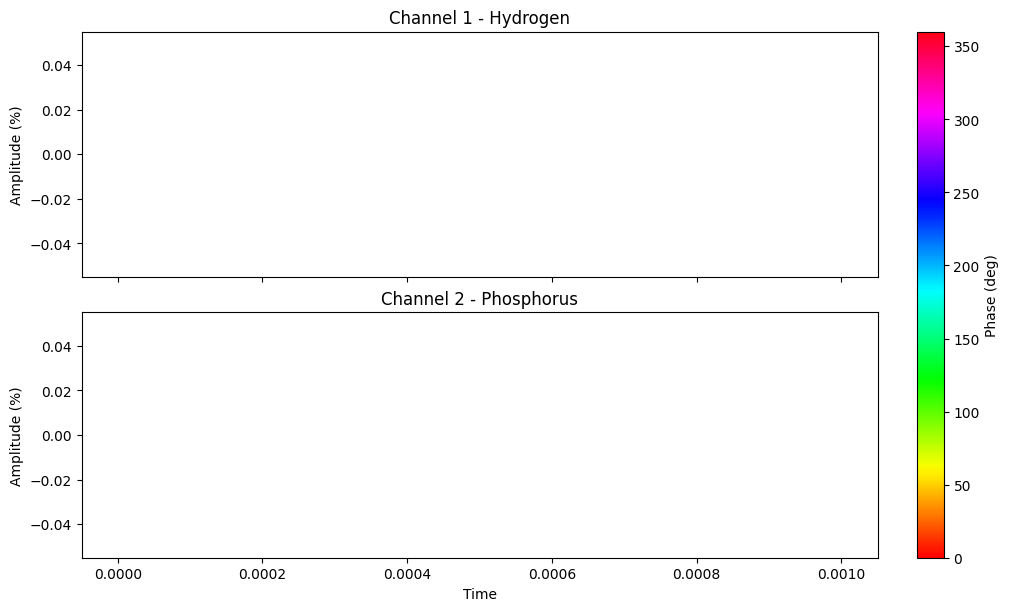

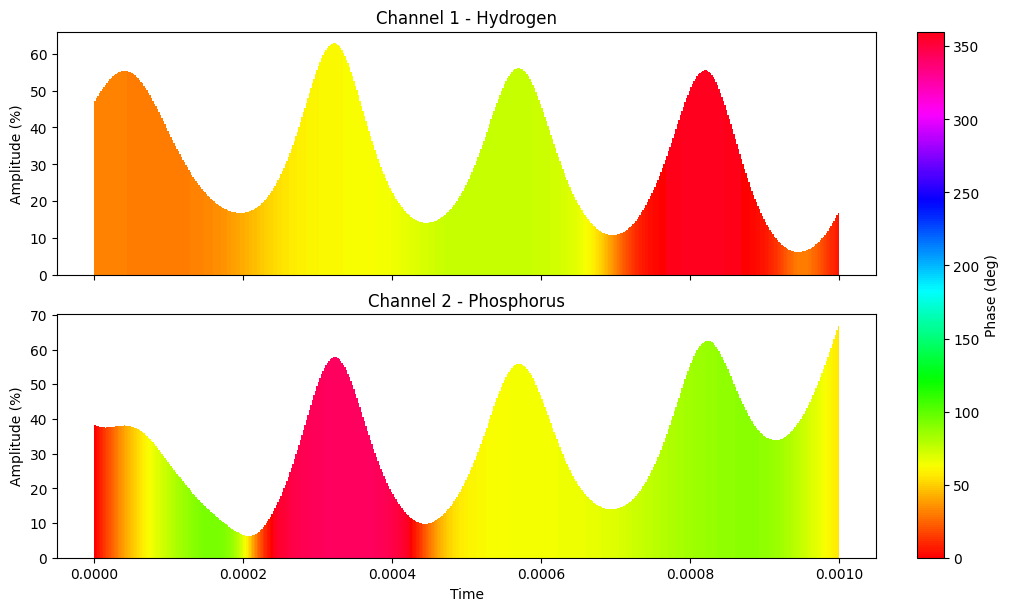

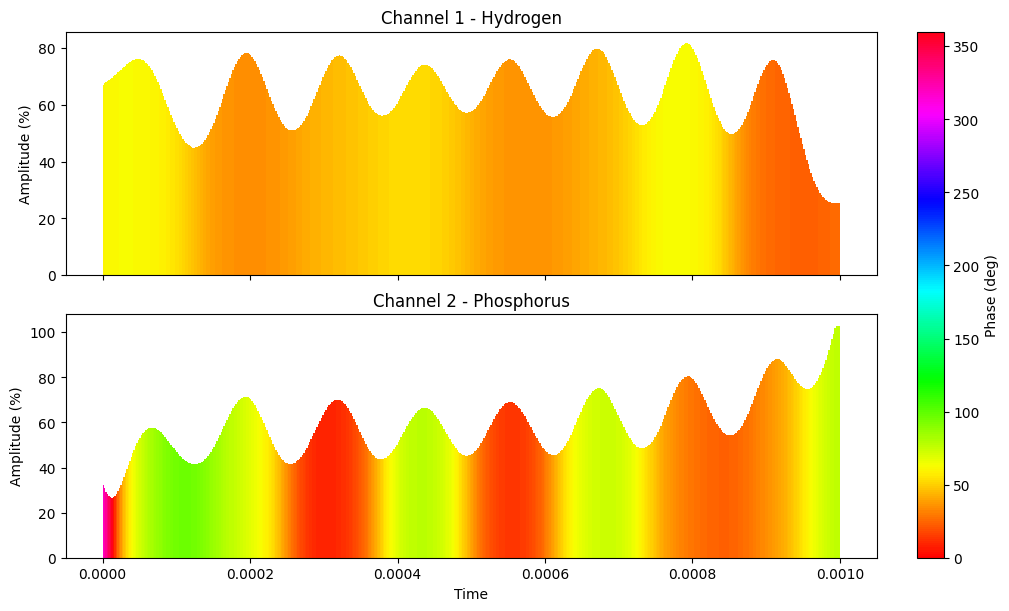

In [8]:
plot_pulse_from_json("TestGRAPE_cnot.json")
plot_pulse_from_json("TestGRAPE_cnot_zero_start.json")
plot_pulse_from_json("TestGRAPE_cnot_point2_start.json")
plot_pulse_from_json("TestGRAPE_cnot_point5_start.json")

In [ ]:
# learning loop --- Exercise Rotations
# NOTES:
# 
np.random.seed(1234)

J = 696
T = 1e-3    # 1ms so J coupling spin-spin interactions have time to evolve
N = 500     # add more divisions if the fidelity doesnt increase monotonically. dt has to be small enough

Rx_H, Ry_H, Rx_P, Ry_P = pulse_optimize_grape(U,J,T,N,0.01,5000)

Target matrix: 
 [[ 0.8392-0.1136j  0.3991-0.0133j -0.2826+0.0629j -0.1991-0.j    ]
 [-0.3088+0.2879j  0.6379-0.4843j  0.0969-0.107j  -0.3259+0.2307j]
 [ 0.1646+0.2581j  0.0969+0.107j   0.5435+0.7115j  0.1871+0.221j ]
 [-0.1047-0.j      0.4162-0.0706j -0.305 +0.0258j  0.8392-0.1136j]]
dt =  2e-06
Iter 0, Fidelity = 0.325959, lr = 1.000000e-02
Iter 100, Fidelity = 0.849218, lr = 1.000000e-02
Iter 200, Fidelity = 0.960366, lr = 1.000000e-02
Iter 300, Fidelity = 0.975567, lr = 1.000000e-02
Iter 400, Fidelity = 0.982338, lr = 1.000000e-02
Iter 500, Fidelity = 0.986502, lr = 1.000000e-02
Iter 600, Fidelity = 0.989297, lr = 1.000000e-02
Iter 700, Fidelity = 0.991259, lr = 1.000000e-02
Iter 800, Fidelity = 0.992674, lr = 1.000000e-02
Iter 900, Fidelity = 0.993712, lr = 1.000000e-02
Iter 1000, Fidelity = 0.994484, lr = 1.000000e-02
Iter 1100, Fidelity = 0.995064, lr = 1.000000e-02
Iter 1200, Fidelity = 0.995504, lr = 1.000000e-02
Iter 1300, Fidelity = 0.995841, lr = 1.000000e-02
Iter 1400, Fid

In [16]:
export_to_json_GRAPE_2channel("TestGRAPE_hardpulses","HardPulseSequence",F,T,N,Rx_H,Ry_H,Rx_P,Ry_P,"andreroque")

Pulse file saved to TestGRAPE_hardpulses


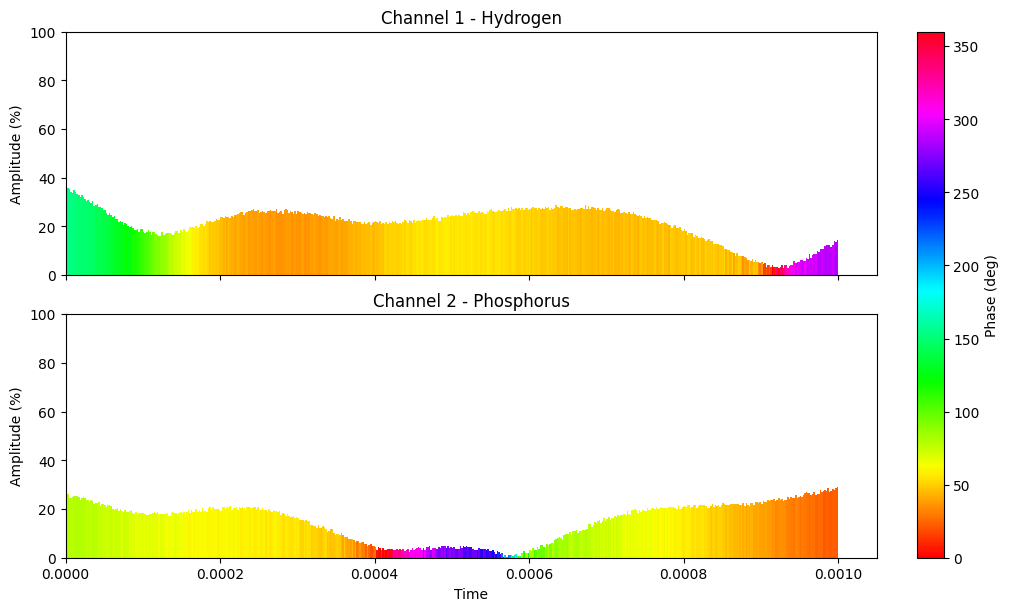

In [8]:
plot_pulse_from_json("pulses/TestGRAPE_hardpulses.json")

In [ ]:
# learning loop --- Hadamard
# NOTES:
# 

np.random.seed(1234)
U_hadamard = 0.5* np.array([[1,1,1,1],
                        [1,-1,1,-1],
                        [1,1,-1,-1],
                        [1,-1,-1,1]])
print("Target matrix: \n", U_target)

J = 696
T = 1e-3    # 1ms so J coupling spin-spin interactions have time to evolve
N = 500     # add more divisions if the fidelity doesnt increase monotonically. dt has to be small enough

Rx_H, Ry_H, Rx_P, Ry_P = pulse_optimize_grape(U_hadamard,J,T,N,0.01,5000)

Target matrix: 
 [[ 0.5  0.5  0.5  0.5]
 [ 0.5 -0.5  0.5 -0.5]
 [ 0.5  0.5 -0.5 -0.5]
 [ 0.5 -0.5 -0.5  0.5]]
dt =  2e-06
Iter 0, Fidelity = 0.103521, lr = 1.000000e-02
Iter 100, Fidelity = 0.211560, lr = 1.000000e-02
Iter 200, Fidelity = 0.318850, lr = 1.000000e-02
Iter 300, Fidelity = 0.401317, lr = 1.000000e-02
Iter 400, Fidelity = 0.460506, lr = 1.000000e-02
Iter 500, Fidelity = 0.498963, lr = 1.000000e-02
Iter 600, Fidelity = 0.525417, lr = 1.000000e-02
Iter 700, Fidelity = 0.545346, lr = 1.000000e-02
Iter 800, Fidelity = 0.561441, lr = 1.000000e-02
Iter 900, Fidelity = 0.575055, lr = 1.000000e-02
Iter 1000, Fidelity = 0.586938, lr = 1.000000e-02
Iter 1100, Fidelity = 0.597545, lr = 1.000000e-02
Iter 1200, Fidelity = 0.607167, lr = 1.000000e-02
Iter 1300, Fidelity = 0.615994, lr = 1.000000e-02
Iter 1400, Fidelity = 0.624147, lr = 1.000000e-02
Iter 1500, Fidelity = 0.631705, lr = 1.000000e-02
Iter 1600, Fidelity = 0.638718, lr = 1.000000e-02
Iter 1700, Fidelity = 0.645221, lr = 1.0

In [ ]:
# learning loop --- BELL STATE
# NOTES:
# needs more than 1ms, fidelity is stuck at 0.25

np.random.seed(1234)
U_bell = np.array([[1,0,0,1],
                    [0,0,0,0],
                    [0,0,0,0],
                    [1,0,0,1]])

J = 696
T = 2e-3    # 1ms so J coupling spin-spin interactions have time to evolve
N = 1000     # add more divisions if the fidelity doesnt increase monotonically. dt has to be small enough

Rx_H, Ry_H, Rx_P, Ry_P = pulse_optimize_grape(U_bell,J,T,N,0.01,5000)

Target matrix: 
 [[1 0 0 1]
 [0 0 0 0]
 [0 0 0 0]
 [1 0 0 1]]
dt =  2e-06
Iter 0, Fidelity = 0.019008, lr = 1.000000e-02
Iter 100, Fidelity = 0.249971, lr = 1.000000e-02
Iter 200, Fidelity = 0.249991, lr = 1.000000e-02
Iter 300, Fidelity = 0.249991, lr = 1.000000e-02
Iter 400, Fidelity = 0.249991, lr = 1.000000e-02
Iter 500, Fidelity = 0.249991, lr = 1.000000e-02
Iter 600, Fidelity = 0.249991, lr = 1.000000e-02
Iter 700, Fidelity = 0.249991, lr = 1.000000e-02
Iter 800, Fidelity = 0.249991, lr = 1.000000e-02
Iter 900, Fidelity = 0.249991, lr = 1.000000e-02
Iter 1000, Fidelity = 0.249991, lr = 1.000000e-02
Iter 1100, Fidelity = 0.249991, lr = 1.000000e-02
Iter 1200, Fidelity = 0.249991, lr = 1.000000e-02
Iter 1300, Fidelity = 0.249991, lr = 1.000000e-02
Iter 1400, Fidelity = 0.249991, lr = 1.000000e-02
Iter 1500, Fidelity = 0.249991, lr = 1.000000e-02
Iter 1600, Fidelity = 0.249991, lr = 1.000000e-02
Iter 1700, Fidelity = 0.249991, lr = 1.000000e-02
Iter 1800, Fidelity = 0.249991, lr = 1

#### Full Pulse Duration study 

In [41]:
pulse_durations = np.logspace(-5,-1,80)
pulse_durations

array([0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001,
       0.0002, 0.0002, 0.0002, 0.0002, 0.0003, 0.0003, 0.0003, 0.0004, 0.0004, 0.0005, 0.0005, 0.0006, 0.0007, 0.0007, 0.0008, 0.0009, 0.0011, 0.0012, 0.0013, 0.0015, 0.0017, 0.0019, 0.0021, 0.0024,
       0.0027, 0.003 , 0.0034, 0.0038, 0.0043, 0.0048, 0.0054, 0.0061, 0.0068, 0.0077, 0.0086, 0.0097, 0.0109, 0.0123, 0.0138, 0.0155, 0.0174, 0.0195, 0.022 , 0.0247, 0.0277, 0.0312, 0.035 , 0.0393,
       0.0442, 0.0497, 0.0558, 0.0627, 0.0705, 0.0792, 0.089 , 0.1   ])

In [42]:
pulse_durations = np.logspace(-5,-1,80)

J = 696
dt = 1e-3/500 # standardize small pulse division

fidelity_values = []

for t in pulse_durations:
    
    N = int(np.round(t / dt))   # scale N with pulse length
    N = max(N, 10)
    
    Rx_H, Ry_H, Rx_P, Ry_P, F = pulse_optimize_grape(U_cnot, J, t, N, 0.01, 5000)
    
    fidelity_values.append(F)
    
fidelity_values = np.array(fidelity_values)

# Plot
plt.figure(figsize=(8,6))
plt.plot(pulse_durations, fidelity_values, linewidth=2)

plt.xscale('log')
plt.xlabel("Pulse Duration (s)", fontsize=12)
plt.ylabel("Fidelity", fontsize=12)
plt.title("GRAPE Optimized CNOT Fidelity vs Pulse Duration", fontsize=14)

plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Final fidelity: 0.2499570905106068
Final fidelity: 0.249956729059632
Final fidelity: 0.24995013882623157
Final fidelity: 0.24994006421435735
Final fidelity: 0.24992400675674747
Final fidelity: 0.24990425249993165
Final fidelity: 0.24987978177297748
Final fidelity: 0.24984824126038338
Final fidelity: 0.24980797733332039
Final fidelity: 0.2497619820112312
Final fidelity: 0.2496932741150719
Final fidelity: 0.24962240339469136
Final fidelity: 0.24951445621289065
Final fidelity: 0.2493879092334724
Final fidelity: 0.24925621515603535
Final fidelity: 0.24914384941396922
Final fidelity: 0.24899873487936763
Final fidelity: 0.2606571034139509
Final fidelity: 0.24898482515822962
Final fidelity: 0.49495927563681813
Final fidelity: 0.4964578417576347
Final fidelity: 0.49698095422587185
Final fidelity: 0.4979141809529333
Final fidelity: 0.5020430155280091
Final fidelity: 0.4998931764518262
Final fidelity: 0.5253824645336664
Final fidelity: 0.5382932052529673
Final fidelity: 0.5954561565584501
Final 

KeyboardInterrupt: 

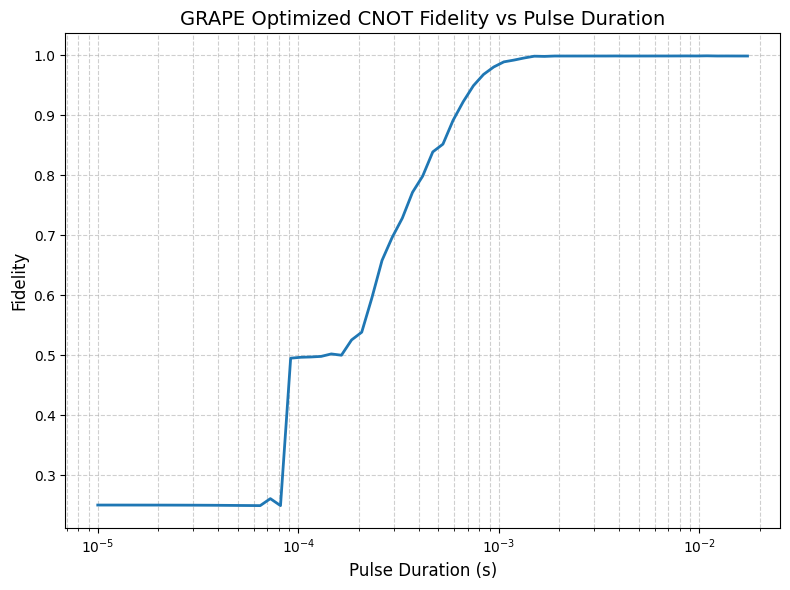

In [46]:
fidelity_values = np.array([0.2499570905106068, 0.249956729059632, 0.24995013882623157, 0.24994006421435735, 
                            0.24992400675674747, 0.24990425249993165, 0.24987978177297748, 0.24984824126038338,
                            0.24980797733332039, 0.2497619820112312, 0.2496932741150719, 0.24962240339469136,
                            0.24951445621289065, 0.2493879092334724, 0.24925621515603535, 0.24914384941396922,
                            0.24899873487936763, 0.2606571034139509, 0.24898482515822962, 0.49495927563681813,
                            0.4964578417576347, 0.49698095422587185, 0.4979141809529333, 0.5020430155280091,
                            0.4998931764518262, 0.5253824645336664, 0.5382932052529673, 0.5954561565584501,
                            0.6580393104729735, 0.6964458122044451, 0.7285958177130991, 0.7715564826674698,
                            0.7985674964156239, 0.8390685119997623, 0.8520195351197392, 0.8917771090065802,
                            0.922887875256714, 0.9494753456769658, 0.9682961855740441, 0.9806961503794439,
                            0.9892381107800494, 0.9922304310142293, 0.9957336094052603, 0.9987064829736354,
                            0.9983660168130406, 0.999000017076195, 0.9990011584225594, 0.99900052860983,
                            0.9990032391343698, 0.999017523257675, 0.9990095892796054, 0.9990803948972756,
                            0.9990029384355726, 0.9990277202831322, 0.9990176521059417, 0.9990626049655393,
                            0.999045229941893, 0.9990854234628223, 0.9991456193125605, 0.9990745639702121,
                            0.9993247502084467, 0.9990414715965595, 0.9990700495372132, 0.9990136258316479, 0.9990030076540936])

pulse_durations = np.logspace(-5,-1,80)
pulse_durations = pulse_durations[:65]

plt.figure(figsize=(8,6))
plt.plot(pulse_durations, fidelity_values, linewidth=2)

plt.xscale('log')
plt.xlabel("Pulse Duration (s)", fontsize=12)
plt.ylabel("Fidelity", fontsize=12)
plt.title("GRAPE Optimized CNOT Fidelity vs Pulse Duration", fontsize=14)

plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Curated pulse durations

In [48]:
pulse_durations = np.logspace(np.log10(5e-5),np.log10(5-3),80)

J = 696
dt = 1e-3/500 # standardize small pulse division

fidelity_values = []

for t in pulse_durations:
    
    N = int(np.ceil(t / dt))   # scale N with pulse length
    N = max(20, min(N,3000))
    
    Rx_H, Ry_H, Rx_P, Ry_P, F = pulse_optimize_grape(U_cnot, J, t, N, 0.01, 5000)
    
    fidelity_values.append(F)
    
fidelity_values = np.array(fidelity_values)

# Plot
plt.figure(figsize=(8,6))
plt.plot(pulse_durations, fidelity_values, linewidth=2)

plt.xscale('log')
plt.xlabel("Pulse Duration (s)", fontsize=12)
plt.ylabel("Fidelity", fontsize=12)
plt.title("GRAPE Optimized CNOT Fidelity vs Pulse Duration", fontsize=14)

plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Final fidelity: 0.2493071235917327
Final fidelity: 0.24911252436186138
Final fidelity: 0.24888393424685296
Final fidelity: 0.26940797594772153
Final fidelity: 0.4922162536961969
Final fidelity: 0.4963456351075085
Final fidelity: 0.4968777687579781
Final fidelity: 0.4973702425984251
Final fidelity: 0.4980931148512654
Final fidelity: 0.49928305114234167
Final fidelity: 0.5247860615855363
Final fidelity: 0.5948383427982634
Final fidelity: 0.6500470398319254
Final fidelity: 0.6849721242398324
Final fidelity: 0.7320928720815588
Final fidelity: 0.7651562135863269
Final fidelity: 0.8123241259168078
Final fidelity: 0.8536018946342092
Final fidelity: 0.8754599485420169
Final fidelity: 0.9138477753884615
Final fidelity: 0.9450362654517679
Final fidelity: 0.9674706875782548
Final fidelity: 0.9819808999753337
Final fidelity: 0.9904708240984882
Final fidelity: 0.9939149571512482
Final fidelity: 0.9982161325157101
Final fidelity: 0.998016165777651
Converged.
Final fidelity: 0.9990001133489416
Conver

KeyboardInterrupt: 

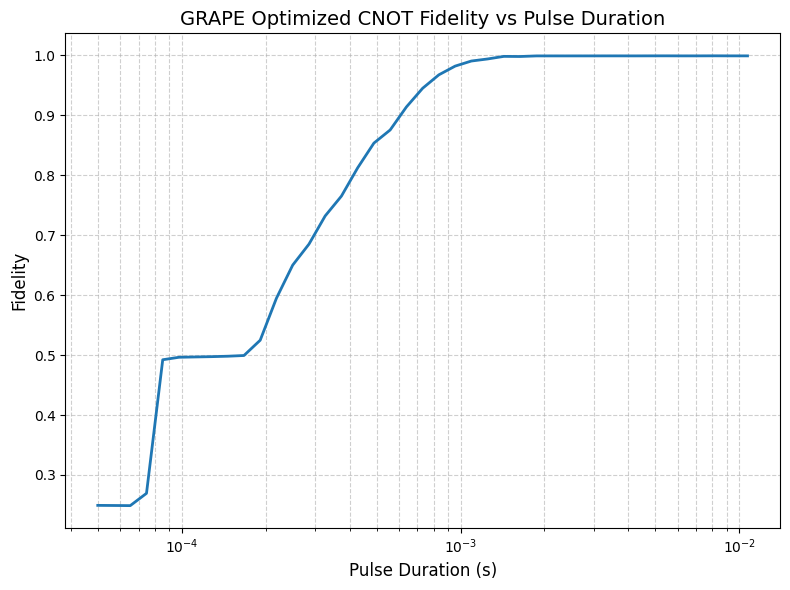

In [52]:

pulse_durations = np.logspace(np.log10(5e-5),np.log10(5-3),80)
pulse_durations = pulse_durations[:len(fidelity_values)-7]

plt.figure(figsize=(8,6))
plt.plot(pulse_durations, fidelity_values[:len(fidelity_values)-7], linewidth=2)

plt.xscale('log')
plt.xlabel("Pulse Duration (s)", fontsize=12)
plt.ylabel("Fidelity", fontsize=12)
plt.title("GRAPE Optimized CNOT Fidelity vs Pulse Duration", fontsize=14)

plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [56]:
print(pulse_durations[5])

9.77776565006807e-05


In [61]:
1/(15*696)

9.578544061302682e-05

In [69]:
print(pulse_durations[12])
print(pulse_durations[23])
print(pulse_durations[24])

0.00025004437645344973
0.0010934785166844489
0.0012504438039198887


In [71]:
1/J

0.0014367816091954023

In [107]:
10**-3.5

0.00031622776601683794

Select a few to save as json, plot to see if smooth, and test experimentally.

In [18]:
pulse_durations = np.array([5e-4,8e-4,1e-3,3e-3])

J = 696
dt = 1e-3/500 # standardize small pulse division
id = 1


fidelity_values = []

for t in pulse_durations:
    
    N = int(np.ceil(t / dt))   # scale N with pulse length
    N = max(20, min(N,3000))
    
    start_parameters = np.array([np.full(N, 0.2),
                                np.full(N, 0.2),
                                np.full(N, 0.2),
                                np.full(N, 0.2)])
    
    Rx_H, Ry_H, Rx_P, Ry_P, F = pulse_optimize_grape(U_cnot, J, t, N, 0.01, 5000, start_parameters)
    
    fidelity_values.append(F)
    
    export_to_json_GRAPE_2channel("pulseCNOT_0."+str(id),"CNOT pulse start=0.2",F,t,N,Rx_H,Ry_H,Rx_P,Ry_P,"andreroque")
    id+=1
    
fidelity_values = np.array(fidelity_values)

Final fidelity: 0.8389756819130217
Pulse file saved to pulseCNOT_0.1
Final fidelity: 0.9627439798456214
Pulse file saved to pulseCNOT_0.2
Final fidelity: 0.967312429511691
Pulse file saved to pulseCNOT_0.3
Converged.
Final fidelity: 0.9990065515858073
Pulse file saved to pulseCNOT_0.4


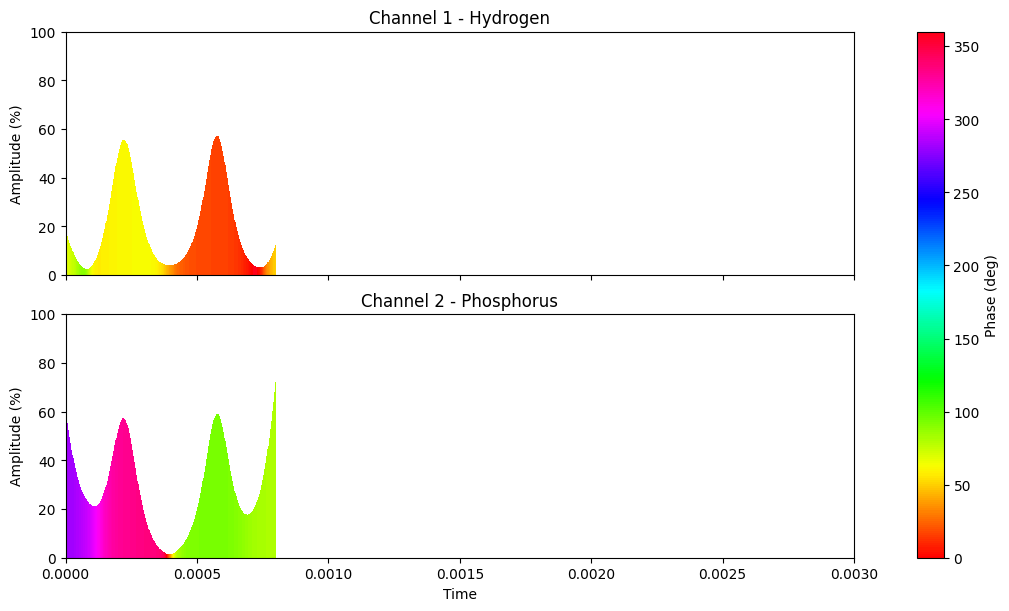

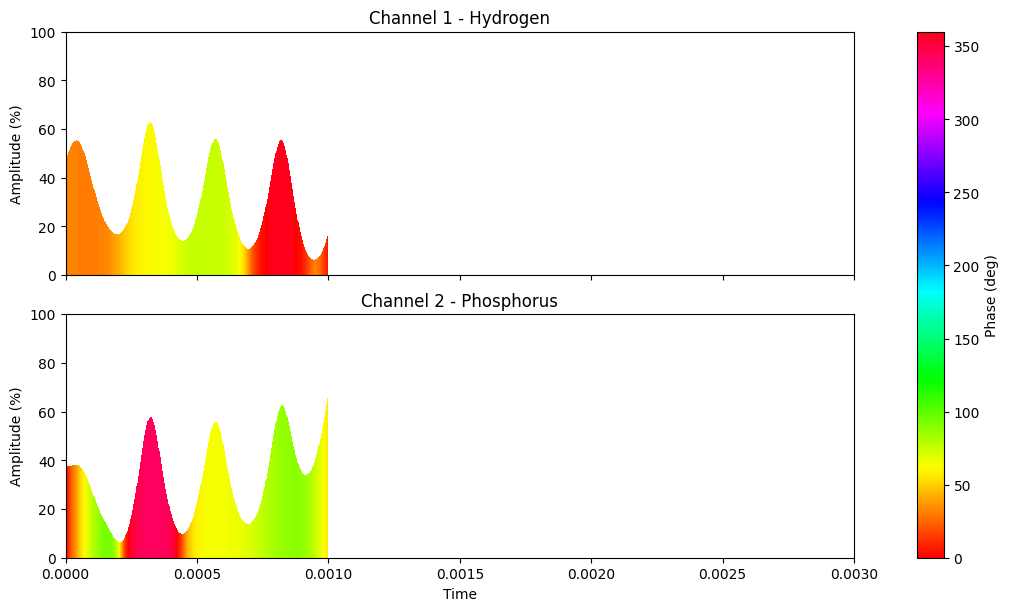

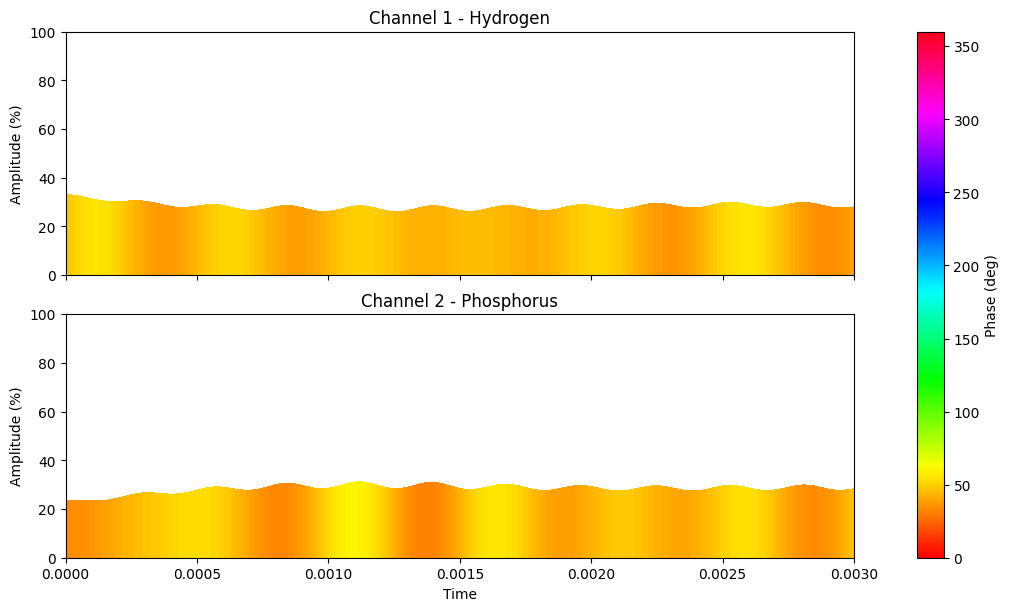

In [31]:
# plot_pulse_from_json("pulseCNOT_0.1.json")
plot_pulse_from_json("pulses/pulseCNOT_0.2.json")
plot_pulse_from_json("pulses/pulseCNOT_0.3.json")
plot_pulse_from_json("pulses/pulseCNOT_0.4.json")

Compute gate fidelity as:

$$
F = \frac{1}{N}\sum_i{P_{correct}(i)}
$$

Experimental Fidelity: 0.2880419852953178
Estado inicial: |00> Estado esperado: |00>


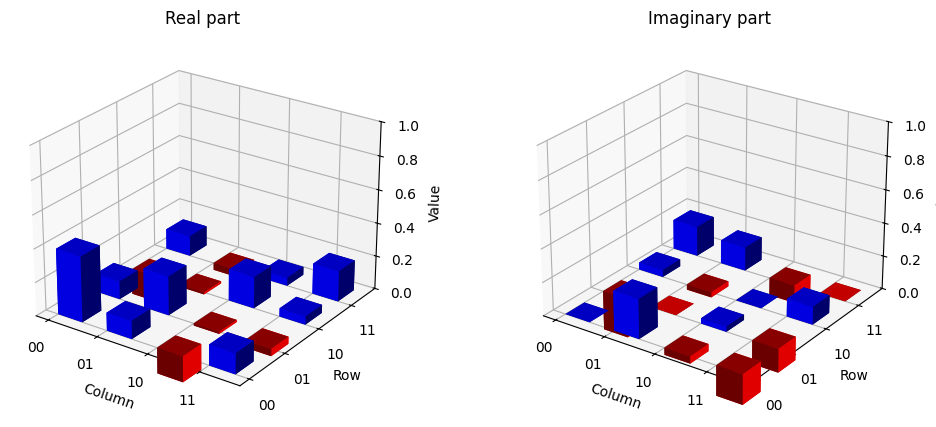

Estado inicial: |10> Estado esperado |11>


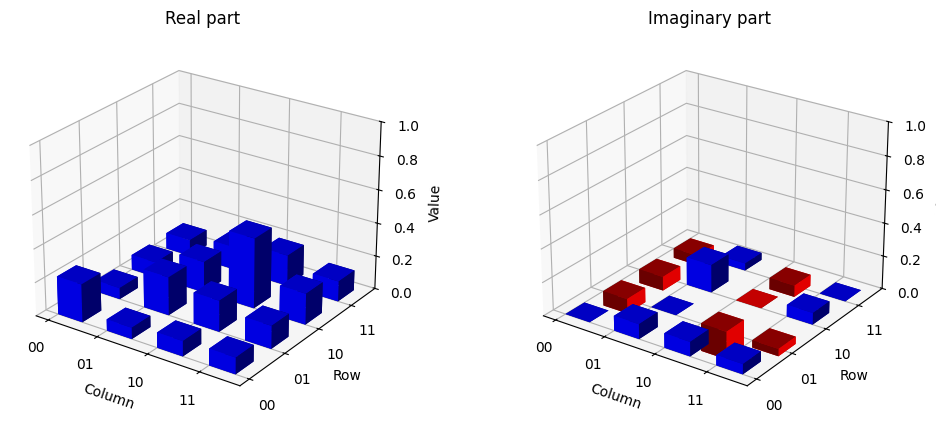

Estado inicial: |01> Estado esperado |01>


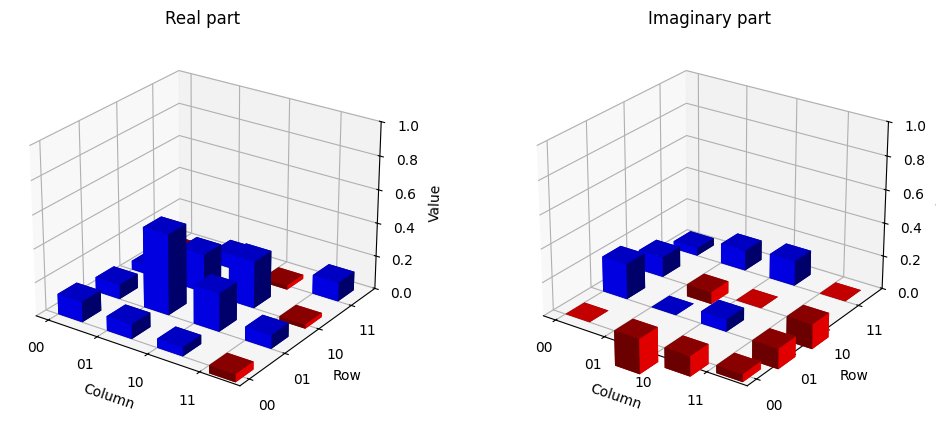

Estado inicial: |11> Estado esperado |10>


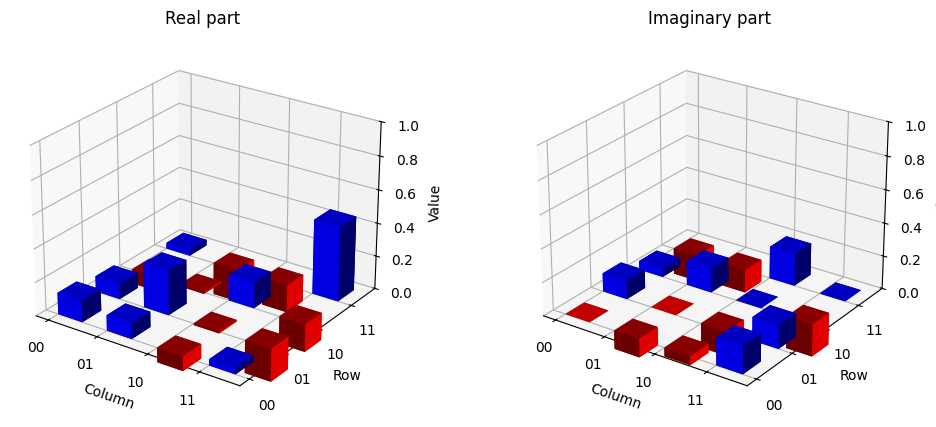

In [ ]:
# PULSE: pulseCNOT_0.4.json

# THEORETICAL FIDELITY: 0.9990065515858073
# TOTALPULSEWIDTH: 0.003
# SLICES: 1500

# |00> probability: prob1
# |10> probability: prob2
# |01> probability: prob3
# |11> probability: prob4

prob1 = [0.3932991511217047, 0.2341546984179476, 0.1889027429739534, 0.18364340748639435]
prob2 = [0.22776086812868415, 0.22909029291621363, 0.4211641783071415, 0.1219846606479609]
prob3 = [0.12231623526677843, 0.4824414545575446, 0.2812499065790344, 0.11399240359664257]
prob4 = [0.1290207246038223, 0.266414674635076, 0.15444267485406107, 0.4501219259070409]

Fvalue = 1/4*(prob1[0]+prob2[3]+prob3[1]+prob4[2])
print(f"Experimental Fidelity: {Fvalue}")

matrix1 = {'real': [0.3932991511217047, 0.10777186178697026, -0.1545938408213187, 0.12220181727709113, 0.10777186178697039, 0.2341546984179476, -0.012908909674977681, -0.04326716668925996, -0.15459384082131875, -0.012908909674977612, 0.1889027429739534, 0.04930533879954199, 0.12220181727709122, -0.04326716668925987, 0.04930533879954198, 0.18364340748639435], 'imag': [3.374608126652734e-17, 0.23849810750536107, -0.04292138543786644, -0.1806617935712935, -0.2384981075053612, -1.3010426069826053e-17, 0.031476667767038106, -0.1423702680867225, 0.042921385437866416, -0.0314766677670381, 5.490128750923473e-17, 0.10726631209598131, 0.18066179357129353, 0.1423702680867224, -0.10726631209598131, -5.551115123125783e-17]}
matrix2 = {'real': [0.22776086812868415, 0.06769047165835644, 0.09061289257917615, 0.0979228147529654, 0.06769047165835651, 0.22909029291621363, 0.18604836641987813, 0.136828471246992, 0.09061289257917624, 0.1860483664198781, 0.4211641783071415, 0.18581720610967029, 0.09792281475296548, 0.136828471246992, 0.1858172061096704, 0.1219846606479609], 'imag': [1.530094121218599e-18, 0.08887495073364324, 0.0858007848272544, 0.060039668988654205, -0.08887495073364331, 5.0840452741420005e-17, -0.16740169483751396, -0.043961987937226596, -0.08580078482725448, 0.16740169483751396, -5.807596699554385e-17, 0.07023161574068791, -0.060039668988654225, 0.0439619879372267, -0.07023161574068791, 6.358506928448582e-17]}       
matrix3 = {'real': [0.12231623526677843, 0.08690450369286326, 0.054056875355067216, -0.047239720274033184, 0.08690450369286332, 0.4824414545575446, 0.22926391489606215, 0.08150897868247357, 0.054056875355067216, 0.22926391489606218, 0.2812499065790344, -0.025106182616060922, -0.0472397202740331, 0.0815089786824736, -0.025106182616060894, 0.11399240359664257], 'imag': [-3.1330678388378226e-17, -0.21344874393879684, -0.12100247602905555, -0.04604243079477756, 0.21344874393879681, 8.46761896711179e-17, 0.07324800044664183, -0.12212257615097141, 0.12100247602905549, -0.07324800044664184, -4.217546450968612e-17, -0.14993436544537425, 0.046042430794777565, 0.12212257615097138, 0.14993436544537422, -6.938893903907228e-18]}
matrix4 = {'real': [0.1290207246038223, 0.09265664534786369, -0.08746517350807968, 0.03560058864910916, 0.09265664534786375, 0.266414674635076, -0.009900680612997845, -0.19751549097681348, -0.08746517350807974, -0.00990068061299787, 0.15444267485406107, -0.16697299941823368, 0.035600588649109116, -0.19751549097681342, -0.16697299941823368, 0.4501219259070409], 'imag': [-5.865943642409083e-18, -0.110766589941656, -0.05242900881205002, 0.16252070256592635, 0.11076658994165609, -1.1709383462843448e-17, -0.14659495644789491, 0.13945635896242242, 0.052429008812050065, 0.14659495644789494, 4.195862407518902e-17, -0.19511701944726467, -0.16252070256592643, -0.13945635896242237, 0.1951170194472646, 1.8467012316038256e-17]}

print("Estado inicial: |00> Estado esperado: |00>")
plot_density_matrix_separate(grab_state_matrix(matrix1))
print("Estado inicial: |10> Estado esperado |11>")
plot_density_matrix_separate(grab_state_matrix(matrix2))
print("Estado inicial: |01> Estado esperado |01>")
plot_density_matrix_separate(grab_state_matrix(matrix3))
print("Estado inicial: |11> Estado esperado |10>")
plot_density_matrix_separate(grab_state_matrix(matrix4))


Experimental Fidelity: 0.5795497122179443
Estado inicial: |00> Estado esperado: |00>


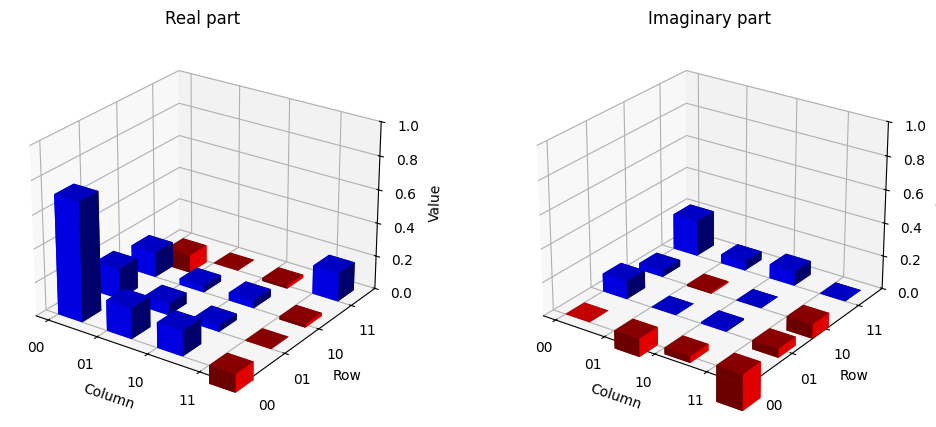

Estado inicial: |10> Estado esperado |11>


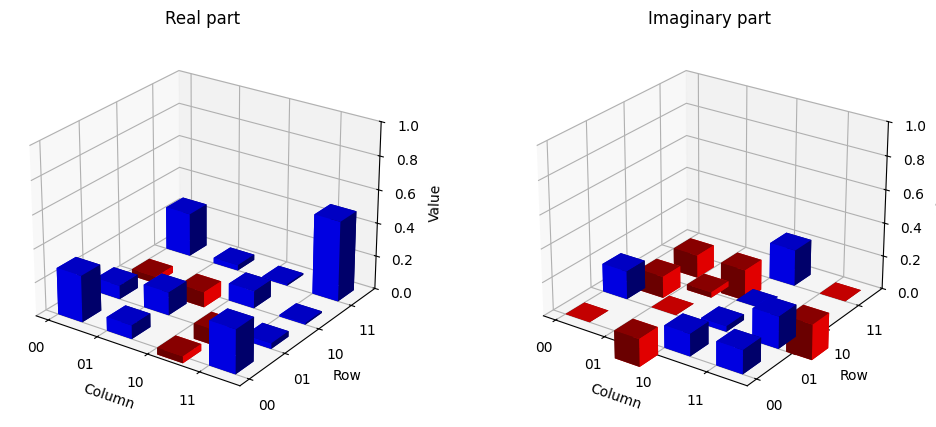

Estado inicial: |01> Estado esperado |01>


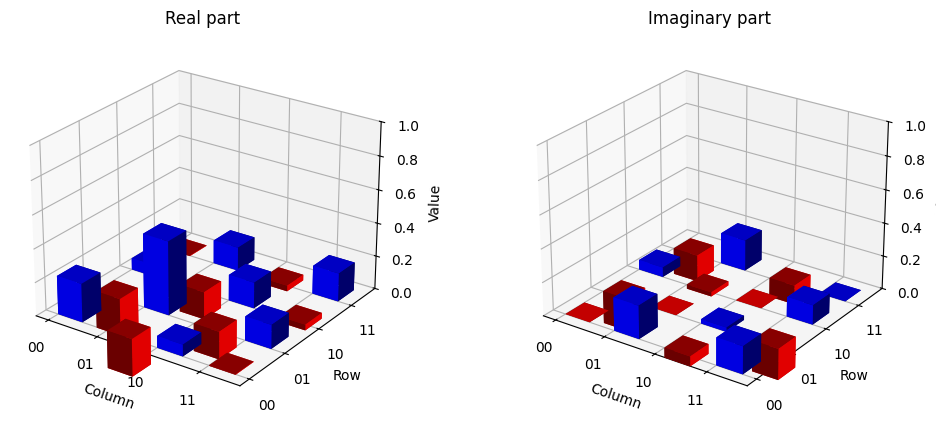

Estado inicial: |11> Estado esperado |10>


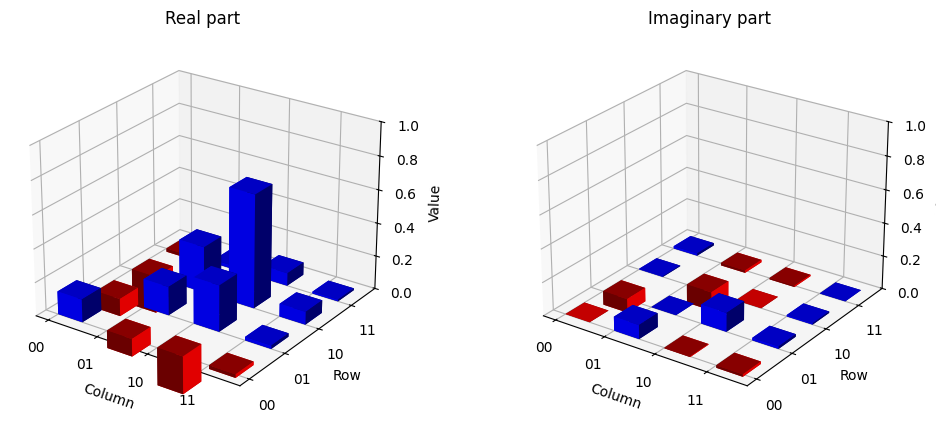

In [ ]:
# PULSE: pulseCNOT_0.3.json

# THEORETICAL FIDELITY: 0.967312429511691
# TOTALPULSEWIDTH: 0.001
# SLICES: 501

# |00> probability: prob1
# |10> probability: prob2
# |01> probability: prob3
# |11> probability: prob4

prob1 = [0.7130446351575593, 0.06754803595506993, 0.04757110386805952, 0.1718362250193119]
prob2 = [0.2784053537717118, 0.136975558269143, 0.10289181982429164, 0.4817272681348538]
prob3 = [0.23088208737905747, 0.443037746340083, 0.15564411144257712, 0.17043605483828175]
prob4 = [0.137303683050508, 0.17109999837506407, 0.680389199239281, 0.01120711933514706]

Fvalue = 1/4*(prob1[0]+prob2[3]+prob3[1]+prob4[2])
print(f"Experimental Fidelity: {Fvalue}")

matrix1 = {'real': [0.7130446351575593, 0.18247122778390626, 0.15068787417326404, -0.10893015363571394, 0.18247122778390631, 0.06754803595506993, 0.03794268000622868, -0.001384791199294114, 0.15068787417326407, 0.03794268000622865, 0.04757110386805952, -0.01872890686075278, -0.10893015363571407, -0.0013847911992941418, -0.018728906860752806, 0.1718362250193119], 'imag': [-3.0995380087047976e-17, -0.10839461231230847, -0.038968725042631935, -0.21731347154724845, 0.10839461231230853, 9.540979117872439e-18, 0.008851128225111462, -0.05355883350306868, 0.03896872504263194, -0.008851128225111454, 3.469446951953614e-18, -0.08582035855196744, 0.2173134715472486, 0.05355883350306863, 0.08582035855196747, 1.3877787807814457e-17]}
matrix2 = {'real': [0.2784053537717118, 0.08132692913877139, -0.04089439618187968, 0.2611545939809199, 0.08132692913877143, 0.136975558269143, -0.0934316323383748, 0.03301084153001281, -0.040894396181879664, -0.09343163233837476, 0.10289181982429164, 0.00968081697263079, 0.26115459398091995, 0.03301084153001276, 0.009680816972630752, 0.4817272681348538], 'imag': [-6.069625852725598e-18, -0.16854762288453373, 0.1324074282565426, 0.1411832056568723, 0.1685476228845338, -3.469446951953614e-18, 0.03334668524735068, 0.19123146029313964, -0.13240742825654261, -0.033346685247350655, 2.2985086056692694e-17, -0.2173017204145183, -0.14118320565687234, -0.1912314602931396, 0.2173017204145183, -3.642919299551295e-17]}  
matrix3 = {'real': [0.23088208737905747, -0.22804185518020043, 0.06987305965900006, -0.002628788388757101, -0.22804185518020043, 0.443037746340083, -0.16815188985722548, 0.14255377461306645, 0.06987305965900005, -0.16815188985722557, 0.15564411144257712, -0.0351130273621155, -0.002628788388757115, 0.14255377461306656, -0.035113027362115516, 0.17043605483828175], 'imag': [-2.521178791379167e-17, 0.19878837534083088, -0.05902763205057189, 0.1637163380315898, -0.19878837534083085, -3.176712365382528e-17, 0.02564392184012829, -0.18710157820528647, 0.05902763205057185, -0.02564392184012821, -1.2956215961201778e-17, 0.11676125775818628, -0.16371633803158983, 0.1871015782052866, -0.11676125775818627, 3.0140820395097023e-17]}
matrix4 = {'real': [0.137303683050508, -0.10562656301125303, -0.22652721767700262, -0.021102435267945505, -0.10562656301125287, 0.17109999837506407, 0.27728221111842055, 0.02041000483278291, -0.22652721767700254, 0.2772822111184208, 0.680389199239281, 0.07706315982769722, -0.021102435267945516, 0.020410004832782956, 0.07706315982769722, 0.01120711933514706], 'imag': [-6.857645705115511e-18, 0.08375203466838624, -0.003860869982565766, -0.014518938149940347, -0.0837520346683862, 6.854868235539602e-17, 0.11326598975679189, 0.015136097081400793, 0.0038608699825657886, -0.11326598975679192, -5.204170427930421e-17, 0.008523524089905976, 0.01451893814994034, -0.015136097081400814, -0.008523524089905993, 4.336808689942018e-19]}

print("Estado inicial: |00> Estado esperado: |00>")
plot_density_matrix_separate(grab_state_matrix(matrix1))
print("Estado inicial: |10> Estado esperado |11>")
plot_density_matrix_separate(grab_state_matrix(matrix2))
print("Estado inicial: |01> Estado esperado |01>")
plot_density_matrix_separate(grab_state_matrix(matrix3))
print("Estado inicial: |11> Estado esperado |10>")
plot_density_matrix_separate(grab_state_matrix(matrix4))

Experimental Fidelity: 0.7153315078635032
Estado inicial: |00> Estado esperado: |00>


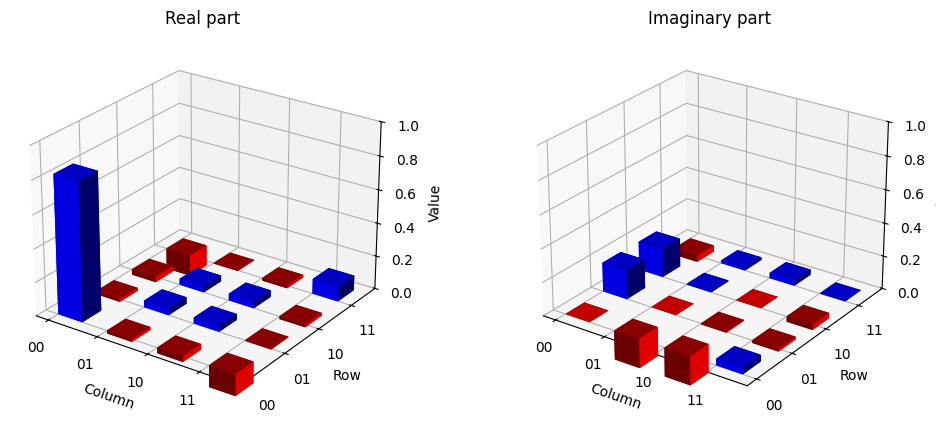

Estado inicial: |10> Estado esperado |11>


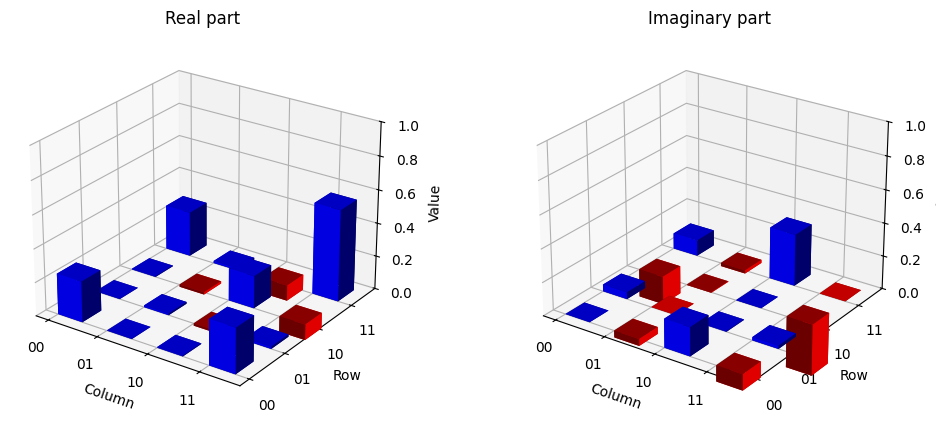

Estado inicial: |01> Estado esperado |01>


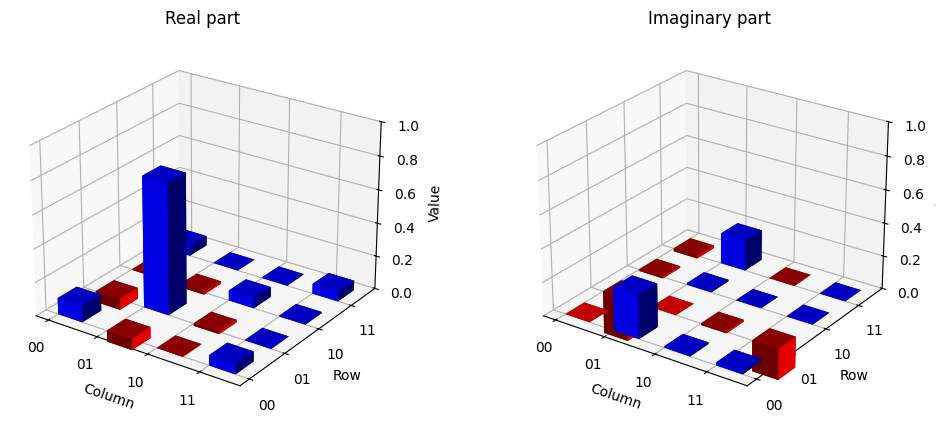

Estado inicial: |11> Estado esperado |10>


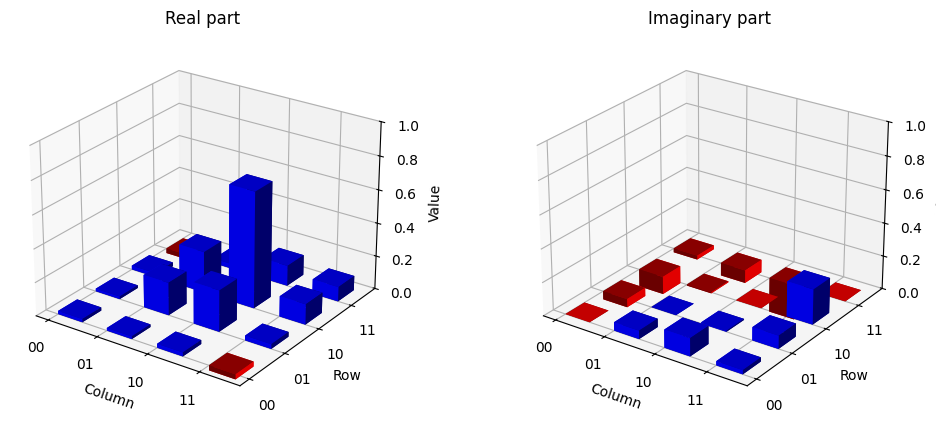

In [ ]:
# PULSE: pulseCNOT_0.2.json

# THEORETICAL FIDELITY: 0.9627439798456214
# TOTALPULSEWIDTH: 0.0008
# SLICES: 401

# |00> probability: prob1
# |10> probability: prob2
# |01> probability: prob3
# |11> probability: prob4

prob1 = [0.83002136402943, 0.03981332946997142, 0.04038955614498017, 0.08977575035561851]
prob2 = [0.24443393398537527, 0.010317080677235087, 0.19437303850319027, 0.5508759468341988]
prob3 = [0.09735776664109909, 0.7833786746408455, 0.06035751929926767, 0.05890603941878841]
prob4 = [0.019283929088916865, 0.19593921699617156, 0.6970500459495383, 0.08772680796537415]

Fvalue = 1/4*(prob1[0]+prob2[3]+prob3[1]+prob4[2])
print(f"Experimental Fidelity: {Fvalue}")

matrix1 = {'real': [0.83002136402943, -0.017278625465322352, -0.0332339344345611, -0.12874830746712465, -0.017278625465322335, 0.03981332946997142, 0.0362147365620196, -0.0035929116025149614, -0.033233934434561116, 0.03621473656201962, 0.04038955614498017, -0.016470497605274293, -0.12874830746712468, -0.0035929116025149622, -0.016470497605274293, 0.08977575035561851], 'imag': [-3.3234361478693577e-19, -0.1757290257142645, -0.17328560518535122, 0.03962882140799004, 0.1757290257142645, -3.686287386450715e-18, -0.005692615995884087, -0.015907234260517204, 0.17328560518535133, 0.0056926159958840886, -6.505213034913027e-19, -0.03263941547410043, -0.03962882140799006, 0.015907234260517197, 0.032639415474100424, 6.938893903907228e-18]}
matrix2 = {'real': [0.24443393398537527, 0.000701737109167256, 0.0037086559266755496, 0.2707557345437631, 0.0007017371091672707, 0.010317080677235087, -0.013590879659908857, 0.013177122249752534, 0.003708655926675613, -0.013590879659908857, 0.19437303850319027, -0.09398620860965859, 0.27075573454376306, 0.013177122249752506, -0.09398620860965862, 0.5508759468341988], 'imag': [5.0249041576139365e-17, -0.04140543745039425, 0.17181212245166322, -0.09595602101074359, 0.041405437450394246, -2.0599841277224584e-18, 0.0026991418899313755, 0.019334414698943873, -0.1718121224516632, -0.0026991418899313577, 8.998878031629687e-18, -0.3132137585292315, 0.09595602101074369, -0.019334414698943897, 0.3132137585292316, -2.5587171270657905e-17]}
matrix3 = {'real': [0.09735776664109909, -0.06685339827348039, -0.0028276086323381832, 0.05962401292427541, -0.06685339827348039, 0.7833786746408455, -0.014475670483994535, 0.0021877852313081556, -0.0028276086323381737, -0.014475670483994531, 0.06035751929926767, 0.00531720187948646, 0.05962401292427543, 0.0021877852313081482, 0.005317201879486467, 0.05890603941878841], 'imag': [-5.501733233142349e-18, 0.2612816290593631, 0.009754225893229957, 0.018060261464379935, -0.2612816290593631, -5.421010862427522e-20, -0.009649723141670861, -0.18674028927776024, -0.009754225893229952, 0.009649723141670884, 3.482999479109683e-18, 0.0016234431353640418, -0.018060261464379942, 0.18674028927776026, -0.0016234431353640342, 1.938011383317839e-18]}
matrix4 = {'real': [0.019283929088916865, 0.015976600569615113, 0.02359606601286631, -0.029715202765184627, 0.015976600569615106, 0.19593921699617156, 0.2475787419855719, 0.028228304849097295, 0.023596066012866325, 0.24757874198557195, 0.6970500459495383, 0.12268955483075863, -0.029715202765184627, 0.028228304849097267, 0.12268955483075852, 0.08772680796537415], 'imag': [-4.057969083457836e-18, 0.050483824199468626, 0.10771743664754267, 0.024746052753249037, -0.050483824199468626, 7.28583859910259e-17, 0.006312435975357845, 0.07900284684106165, -0.10771743664754269, -0.006312435975357668, -2.5153490401663703e-17, 0.21186679069688105, -0.024746052753249016, -0.0790028468410616, -0.21186679069688105, -3.539920093165172e-17]}

print("Estado inicial: |00> Estado esperado: |00>")
plot_density_matrix_separate(grab_state_matrix(matrix1))
print("Estado inicial: |10> Estado esperado |11>")
plot_density_matrix_separate(grab_state_matrix(matrix2))
print("Estado inicial: |01> Estado esperado |01>")
plot_density_matrix_separate(grab_state_matrix(matrix3))
print("Estado inicial: |11> Estado esperado |10>")
plot_density_matrix_separate(grab_state_matrix(matrix4))

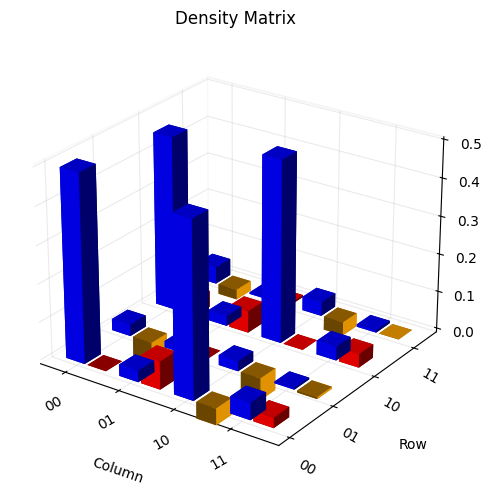

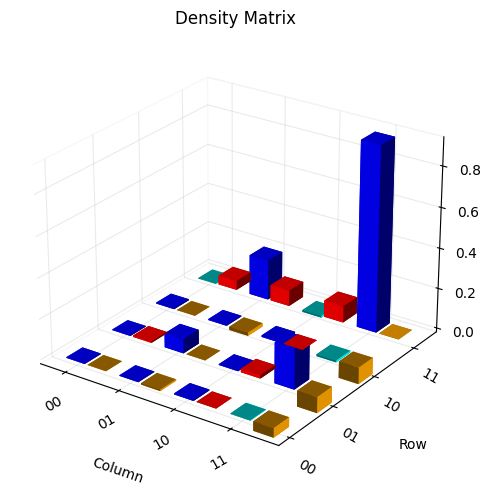

In [15]:
test_matrix_4 = {'real': [0.49544518446567637, 0.030296334245481848, 0.4616990361193888, 0.04486351133985317, 0.03029633424548179, 0.017080360739357498, 0.02656239479227129, 0.004468100242953722, 0.4616990361193888, 0.026562394792271363, 0.48080644933090205, 0.03683814932999323, 0.044863511339853133, 0.004468100242953738, 0.036838149329993186, 0.006668005464063742], 'imag': [2.5802526947249844e-18, 0.07351954032876758, -0.04373582377880405, 0.0267272785538043, -0.07351954032876748, 5.095750210681871e-18, -0.05782961777292653, -0.0050580546705466176, 0.04373582377880407, 0.05782961777292661, 2.3852447794681098e-18, 0.035760995256765245, -0.026727278553804336, 0.005058054670546611, -0.03576099525676526, -5.421010862427522e-18]}
plot_density_matrix(grab_state_matrix(test_matrix_4))
test_matrix_3 = {'real': [0.0029028429876387677, 0.0027079791216125648, 0.004522129691854687, -0.0019837015698935417, 0.002707979121612573, 0.06966645600267304, 0.004174044374339053, 0.19993491338011282, 0.004522129691854696, 0.00417404437433906, 0.007664585791879854, -0.009374220756055863, -0.0019837015698935404, 0.19993491338011307, -0.009374220756055932, 0.9197661152178093], 'imag': [-4.7007457582933736e-20, -0.006979014279739406, 0.00025086799301650187, -0.046261999479199144, 0.006979014279739412, -1.6479873021779667e-17, 0.016566384861090487, -0.07827443124396213, -0.0002508679930164982, -0.016566384861090487, 6.661067097207818e-18, -0.0820523468449231, 0.04626199947919923, 0.07827443124396216, 0.08205234684492309, -7.37257477290143e-18]}
plot_density_matrix(grab_state_matrix(test_matrix_3))

FRAUD results :/ 

make sure quantum computer is running the set pulse sequence

redo cnot optimizations with different starting points? any kind of optimization? how to select control qubit?

#### Introduce pulse duration as optimization parameter



In [ ]:
# Gradient Ascent - GRAPE - Pulse duration as optimization parameter

# a bit different from the basic SMP, the parameter phi is omitted, collapsed into the amplitude which now differs for each orthogonal direction x, y

# constants
n = 2
d = 2**n
#wH = 27e6
#wP = 11e6
#w1H = w1P after calibration
w1_max = 6250

H_x_H = 2*np.pi*w1_max*(Ix1)
H_x_P = 2*np.pi*w1_max*(Ix2)
H_y_H = 2*np.pi*w1_max*(Iy1)
H_y_P = 2*np.pi*w1_max*(Iy2)


# H_0 = 0 because on resonance, only include when detuning or counteracting chemical shift mismatch

def p_calc_2channel_withtime(Rx_H, Ry_H, Rx_P, Ry_P, tau, U_target, J, T, N):
    P_list = []
    P = U_target.copy()
    dt = T/N
    H_J0 = 2*np.pi*J*(np.kron(Z,Z)/4)
    for k in reversed(range(N)):
        
        H = tau*H_J0 + Rx_H[k]*H_x_H + Ry_H[k]*H_y_H + Rx_P[k]*H_x_P + Ry_P[k]*H_y_P
        Uk = scipy.linalg.expm(-1j * H * dt)
        P = Uk.conj().T @ P
        P_list.insert(0, P)

    return P_list

def x_calc_2channel_withtime(Rx_H, Ry_H, Rx_P, Ry_P, tau, J, T, N):
    X_list = []
    U = np.eye(d, dtype=complex)
    dt = T/N
    H_J0 = 2*np.pi*J*(np.kron(Z,Z)/4)
    for k in range(N):
        H = tau*H_J0 + Rx_H[k]*H_x_H + Ry_H[k]*H_y_H + Rx_P[k]*H_x_P + Ry_P[k]*H_y_P
        Uk = scipy.linalg.expm(-1j * H * dt)
        U = Uk @ U
        X_list.append(U)

    return X_list, U

def fidelity_grape_withtime(U, U_target):
    phi = np.trace(U_target.conj().T @ U)
    return np.abs(phi)**2/d**2

def grape_grad_2channel_withtime(Rx_H, Ry_H, Rx_P, Ry_P, tau, U_target, J, T, N):
    
    X_list, U_final = x_calc_2channel_withtime(Rx_H, Ry_H, Rx_P, Ry_P, tau, J, T, N)
    P_list = p_calc_2channel_withtime(Rx_H, Ry_H, Rx_P, Ry_P, tau,  U_target, J, T, N)
    dt = T/N
    H_J0 = 2*np.pi*J*(np.kron(Z,Z)/4)
    
    phi = np.trace(U_target.conj().T @ U_final)
    F0 = fidelity_grape_withtime(U_final, U_target)
    
    grad_Rx_H = np.zeros(N)
    grad_Ry_H = np.zeros(N)
    grad_Rx_P = np.zeros(N)
    grad_Ry_P = np.zeros(N)
    grad_tau = 0
    
    for k in range(N):
        Xk = X_list[k]
        Pk = P_list[k]
        
        dX_Rx_H = -1j * dt * H_x_H @ Xk
        dX_Ry_H = -1j * dt * H_y_H @ Xk
        dX_Rx_P = -1j * dt * H_x_P @ Xk
        dX_Ry_P = -1j * dt * H_y_P @ Xk
        dX_tau = -1j * dt * H_J0 @ Xk

        grad_Rx_H[k] = 2 * np.real(
            np.trace(Pk.conj().T @ dX_Rx_H) * np.conj(phi)
        )

        grad_Ry_H[k] = 2 * np.real(
            np.trace(Pk.conj().T @ dX_Ry_H) * np.conj(phi)
        )

        grad_Rx_P[k] = 2 * np.real(
            np.trace(Pk.conj().T @ dX_Rx_P) * np.conj(phi)
        )

        grad_Ry_P[k] = 2 * np.real(
            np.trace(Pk.conj().T @ dX_Ry_P) * np.conj(phi)
        )
        
        grad_tau += 2 * np.real(
            np.trace(Pk.conj().T @ dX_tau) * np.conj(phi)
        )
        
    return (F0, grad_Rx_H, grad_Ry_H, grad_Rx_P, grad_Ry_P, grad_tau, U_final)

def pulse_optimize_grape_withtime(U_target, J, T, N, learn_rate, max_iter, startParameters=None):
    
    # initialize
    if startParameters is not None:
        Rx_H, Ry_H, Rx_P, Ry_P, tau = startParameters
    else:
        Rx_H = 0.2 * np.random.rand(N)
        Ry_H = 0.2 * np.random.rand(N)
        Rx_P = 0.2 * np.random.rand(N)
        Ry_P = 0.2 * np.random.rand(N)
        tau = 1.0

    lr = learn_rate
    maxi = max_iter
    lambda_tau = 0.001  # weight for pulse duration in cost

    for i in range(maxi):

        # compute fidelity and gradients
        F0, gRxH, gRyH, gRxP, gRyP, gTau, Ufinal = grape_grad_2channel_withtime(
            Rx_H, Ry_H, Rx_P, Ry_P, tau, U_target, J, T, N
        )

        # cost function
        cost = (1 - F0)**2 + lambda_tau * tau**2

        # compute cost gradients using chain rule
        # d(cost)/d(control) = 2*(1-F0)*(-grad_F) + 2*lambda_tau*tau
        factor = -2 * (1 - F0)

        Rx_H -= lr * factor * gRxH
        Ry_H -= lr * factor * gRyH
        Rx_P -= lr * factor * gRxP
        Ry_P -= lr * factor * gRyP
        tau -= lr * (factor * gTau + 2 * lambda_tau * tau)

        # Clip amplitudes
        Rx_H = np.clip(Rx_H, -1, 1)
        Ry_H = np.clip(Ry_H, -1, 1)
        Rx_P = np.clip(Rx_P, -1, 1)
        Ry_P = np.clip(Ry_P, -1, 1)
        tau = np.clip(tau, 0.1, 5.0)  # avoid tau=0

        if i % 100 == 0:
            print(f"Iter {i}, Fidelity = {F0:.6f}, Tau = {tau:.4f}, Cost = {cost:.6f}")

        if F0 > 0.999:
            print("Converged.")
            break

    print("Final fidelity:", F0, "Final tau:", tau)
    return Rx_H, Ry_H, Rx_P, Ry_P, tau, F0
    
def export_to_json_GRAPE_2channel_withtime(filename, title, fidelity, T0, slices, Rx_H, Ry_H, Rx_P, Ry_P, tau, owner="Unkown"):
    
    Rx_H = np.asarray(Rx_H).flatten()
    Ry_H = np.asarray(Ry_H).flatten()
    Rx_P = np.asarray(Rx_P).flatten()
    Ry_P = np.asarray(Ry_P).flatten()
    
    totalpulsewidth = T0 * tau
    dt = totalpulsewidth / slices * 1e6 # in microseconds

    channel1_pulses = []
    channel2_pulses = []

    for k in range(slices):

        amplitude_H = 100 * np.sqrt(Rx_H[k]**2 + Ry_H[k]**2) / tau  # percentage
        phase_H = np.degrees(np.arctan2(Ry_H[k], Rx_H[k])) % 360

        amplitude_P = 100 * np.sqrt(Rx_P[k]**2 + Ry_P[k]**2) / tau
        phase_P = np.degrees(np.arctan2(Ry_P[k], Rx_P[k])) % 360
        
        pulse_H = {
            "detuning": 0,
            "phase": float(phase_H),
            "amplitude": float(amplitude_H),
            "width": float(dt)
        }
        pulse_P = {
            "detuning": 0,
            "phase": float(phase_P),
            "amplitude": float(amplitude_P),
            "width": float(dt)
        }

        # Same pulse on both channels (modify if needed)
        channel1_pulses.append(pulse_H)
        channel2_pulses.append(pulse_P)
        
        data = {
        "description": {
            "TITLE": title,
            "OWNER": owner,
            "DATE": datetime.now().strftime("%d-%m-%Y"),
            "FIDELITY": float(fidelity),
            "TOTALPULSEWIDTH": float(totalpulsewidth),
            "SLICES": int(slices)
        },
        "parameters": {
            "offset": [
                {
                    "channel1_pulsefre_offset": 0,
                    "channel1_framefre_offset": 0,
                    "channel2_pulsefre_offset": 0,
                    "channel2_framefre_offset": 0
                }
            ]
        },
        "pulse": {
            "channel1_pulse": channel1_pulses,
            "channel2_pulse": channel2_pulses
        }
    }

    with open(filename, "w") as f:
        json.dump(data, f, indent=4)

    print(f"Pulse file saved to {filename}")
    

In [85]:
# learning loop --- CNOT - with time scaling
# NOTES:
# 
np.random.seed(1234)

J = 696
T = 1e-3    
N = 500     

Rx_H, Ry_H, Rx_P, Ry_P, tau, final_fidelity = pulse_optimize_grape_withtime(U_cnot,J,T,N,0.01,5000)

Iter 0, Fidelity = 0.102051, Tau = 0.9625, Cost = 0.807313
Iter 100, Fidelity = 0.751348, Tau = 0.9237, Cost = 0.062674
Iter 200, Fidelity = 0.834466, Tau = 1.1150, Cost = 0.028643
Iter 300, Fidelity = 0.865019, Tau = 1.1718, Cost = 0.019592
Iter 400, Fidelity = 0.883604, Tau = 1.1996, Cost = 0.014987
Iter 500, Fidelity = 0.897046, Tau = 1.2181, Cost = 0.012083
Iter 600, Fidelity = 0.907502, Tau = 1.2328, Cost = 0.010075
Iter 700, Fidelity = 0.915968, Tau = 1.2455, Cost = 0.008612
Iter 800, Fidelity = 0.923004, Tau = 1.2571, Cost = 0.007508
Iter 900, Fidelity = 0.928963, Tau = 1.2678, Cost = 0.006653
Iter 1000, Fidelity = 0.934086, Tau = 1.2780, Cost = 0.005978
Iter 1100, Fidelity = 0.938540, Tau = 1.2875, Cost = 0.005435
Iter 1200, Fidelity = 0.942450, Tau = 1.2966, Cost = 0.004993
Iter 1300, Fidelity = 0.945909, Tau = 1.3053, Cost = 0.004629
Iter 1400, Fidelity = 0.948990, Tau = 1.3135, Cost = 0.004327
Iter 1500, Fidelity = 0.951749, Tau = 1.3214, Cost = 0.004074
Iter 1600, Fidelity 

In [87]:
# learning loop --- CNOT - with time scaling
# NOTES:
# 
np.random.seed(1234)

J = 696
T = 3e-3    
N = 500     

Rx_H, Ry_H, Rx_P, Ry_P, tau, final_fidelity = pulse_optimize_grape_withtime(U_cnot,J,T,N,0.01,5000)

Iter 0, Fidelity = 0.172957, Tau = 0.9093, Cost = 0.684999
Iter 100, Fidelity = 0.967236, Tau = 0.9363, Cost = 0.001950
Iter 200, Fidelity = 0.982950, Tau = 0.9538, Cost = 0.001200
Iter 300, Fidelity = 0.988377, Tau = 0.9617, Cost = 0.001060
Iter 400, Fidelity = 0.991081, Tau = 0.9664, Cost = 0.001013
Iter 500, Fidelity = 0.992689, Tau = 0.9695, Cost = 0.000993
Iter 600, Fidelity = 0.993752, Tau = 0.9718, Cost = 0.000983
Iter 700, Fidelity = 0.994504, Tau = 0.9736, Cost = 0.000978
Iter 800, Fidelity = 0.995064, Tau = 0.9750, Cost = 0.000975
Iter 900, Fidelity = 0.995496, Tau = 0.9762, Cost = 0.000973
Iter 1000, Fidelity = 0.995839, Tau = 0.9772, Cost = 0.000972
Iter 1100, Fidelity = 0.996117, Tau = 0.9780, Cost = 0.000972
Iter 1200, Fidelity = 0.996348, Tau = 0.9788, Cost = 0.000971
Iter 1300, Fidelity = 0.996541, Tau = 0.9794, Cost = 0.000971
Iter 1400, Fidelity = 0.996706, Tau = 0.9800, Cost = 0.000971
Iter 1500, Fidelity = 0.996848, Tau = 0.9805, Cost = 0.000971
Iter 1600, Fidelity 

In [88]:
# learning loop --- CNOT - with time scaling
# NOTES:
# 
np.random.seed(1234)

J = 696
T = 5e-3    
N = 500     

Rx_H, Ry_H, Rx_P, Ry_P, tau, final_fidelity = pulse_optimize_grape_withtime(U_cnot,J,T,N,0.01,5000)

Iter 0, Fidelity = 0.045042, Tau = 0.9509, Cost = 0.912945
Iter 100, Fidelity = 0.994258, Tau = 0.8481, Cost = 0.000752
Iter 200, Fidelity = 0.996011, Tau = 0.8446, Cost = 0.000729
Iter 300, Fidelity = 0.996569, Tau = 0.8419, Cost = 0.000721
Iter 400, Fidelity = 0.996823, Tau = 0.8395, Cost = 0.000715
Iter 500, Fidelity = 0.996959, Tau = 0.8372, Cost = 0.000710
Iter 600, Fidelity = 0.997039, Tau = 0.8349, Cost = 0.000706
Iter 700, Fidelity = 0.997087, Tau = 0.8327, Cost = 0.000702
Iter 800, Fidelity = 0.997118, Tau = 0.8305, Cost = 0.000698
Iter 900, Fidelity = 0.997137, Tau = 0.8283, Cost = 0.000694
Iter 1000, Fidelity = 0.997149, Tau = 0.8261, Cost = 0.000691
Iter 1100, Fidelity = 0.997156, Tau = 0.8239, Cost = 0.000687
Iter 1200, Fidelity = 0.997159, Tau = 0.8218, Cost = 0.000683
Iter 1300, Fidelity = 0.997160, Tau = 0.8196, Cost = 0.000680
Iter 1400, Fidelity = 0.997158, Tau = 0.8174, Cost = 0.000676
Iter 1500, Fidelity = 0.997155, Tau = 0.8153, Cost = 0.000673
Iter 1600, Fidelity 

Test 0.9+ fidelity pulses experimentally